# Implement folder Planck equation
Find optimal concentration schedule / optimal antigen using analytical formula



In [2]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np


In [3]:

mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001*np.sqrt(40)
p_diff=0.10
c=170# 800, 1120, 920, 510

mu_M=-0.8
sigma_M=1.09


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)
S_mat=[[1.0]]

In [4]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    get_S=lambda t: S_mat,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-3.0, h_max=14.0, d_h=0.05,
    T=30.0,  dt=0.001,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if get_S is None:
        raise ValueError("S_mat (binary motif matrix) must be provided for each time step")
    N_h, n_A = get_S(0).shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        S_mat=get_S(t_now)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives
        # cell_density = 1.0 / dH
        # rho[rho < 0.0001 * cell_density] = 0.0

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [5]:
def run_fp(get_S, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        get_S=get_S, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = get_S(0).shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        E_full    = np.tensordot(get_S(t_now).T, np.stack(h_mesh, axis=0), axes=(1, 0))

        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
        S_torch = torch.tensor(get_S(t_now), dtype=torch.float64)

        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        get_S=get_S, get_C=get_C
    )



In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="viridis",
                             sol=None, t_clip=5.0):
    """
    Heat-map of ρ(t, h_dim), with colour-bar max taken from times ≥ t_clip.

    Parameters
    ----------
    fp_ctx   : dict   – output of run_fp
    dim      : int    – which h-coordinate to show (0-based)
    disp_step: float  – x-tick spacing
    cmap     : str    – Matplotlib colormap
    sol      : BVPResult or None – optional trajectory overlay
    t_clip   : float  – ignore times < t_clip when computing vmax
    """
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)  # +1 for time
    dH = np.prod([(axes[i][1] - axes[i][0]) for i in range(N_h)
                  if i != dim]) if N_h > 1 else 1.0
    rho_marg = rho_t.sum(axis=marginal_axes) * dH                 # (n_t, n_h)

    # --- choose vmax from t ≥ t_clip ----------------------------------
    idx_start = np.searchsorted(times, t_clip)          # first t ≥ t_clip
    vmax_clip = rho_marg[idx_start:].max()

    # --- plot ----------------------------------------------------------
    plt.figure(figsize=(6, 5))
    im = plt.imshow(rho_marg.T, origin="lower", aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, vmin=0.0, vmax=vmax_clip)

    plt.colorbar(im, label=rf"$\rho(t,h_{{{dim+1}}})$")
    plt.xlabel("Time", fontsize=14)
    plt.ylabel(rf"$h_{{{dim+1}}}$", fontsize=14)
    plt.title(rf"Density $\rho(t,h_{{{dim+1}}})$ ")

    plt.xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))

    if sol is not None:
        plt.plot(sol.x, sol.y[dim], color="red", lw=1.4,
                 label=rf"least-action $h_{{{dim+1}}}(t)$")
        plt.legend()

    plt.tight_layout()
    plt.show()






Running FP simulation for T=140 seconds


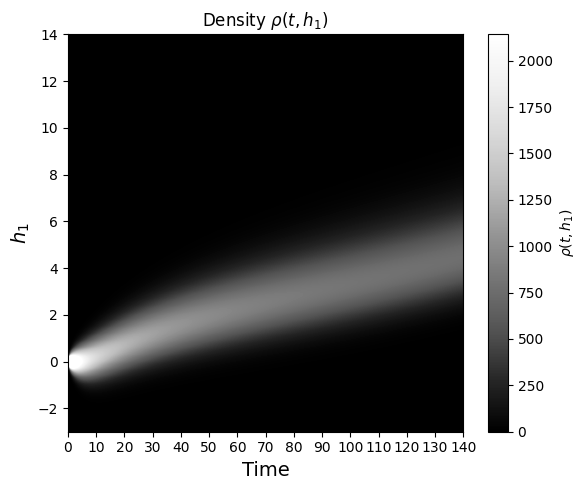

In [7]:
import numpy as np
import copy
T=140
print(f"\nRunning FP simulation for T={T} seconds")
fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")







### Compute C* with one round of convergence

c*(t) at the FP snapshots:
t= 0.000  c*=57.8451
t= 0.005  c*=57.8549
t= 0.010  c*=57.8647
t= 0.015  c*=57.8745
t= 0.020  c*=57.8842


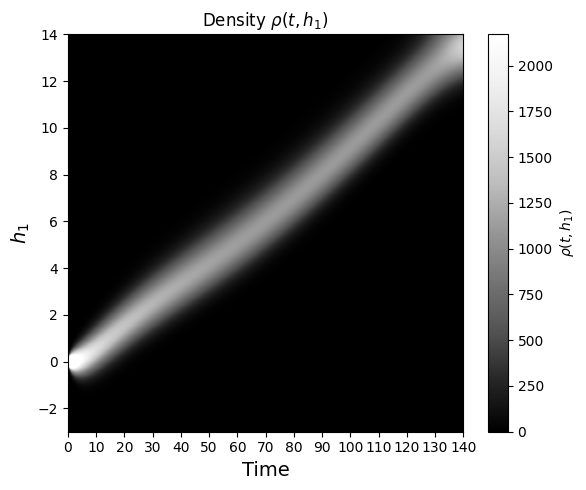

In [8]:
import numpy as np

# ---------- grid measures (time-invariant) ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")  # list length N_h
    return axes, h_mesh, dH

# ---------- E_stack at a given time index k ----------
def _E_stack_at_k(fp_ctx, k, h_mesh):
    """
    Build E_stack_k[v, ...] = E_v(h, t_k) with S(t_k) from get_S.
    """
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]                       # callable: t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))                # (N_h, n_A)
    E_stack_k = np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))
    # shape: (n_A, ...grid...)
    return E_stack_k

# ---------- ⟨log P_Ag + log P_T⟩_pop for a scalar C at time index k ----------
def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop and also (P_Ag + P_T)_pop at snapshot k,
    assuming every antigen has concentration C (scalar).
    """
    axes, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)

    # time-dependent energies via get_S(t_k)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)

    # P_T  (depends only on C_tot)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)

    # population-weighted averages
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop


    # Gates

    # IMPORTANT: recompute Phi_bar for THIS s2
    Phi_bar  = (w_pop * Phi).sum() * dH
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    return avg_log, P_sum_pop

# ---------- solve c*(t_k) for all snapshots ----------
def solve_c_star_over_time(fp_ctx, *, lam=1.0, kBT, E_a,
                           u0=np.log(1.0), newton_maxit=5, newton_tol=1e-10):
    """
    For each k, solve for c* > 0 such that
        <log P_Ag + log P_T>_pop(C=c*) = -lam
    with time-varying S(t_k).
    Newton in u=log C, derivative: d/du <log P_Ag + log P_T> = 2 - (P_Ag+P_T)_pop.
    """
    times  = fp_ctx["times"]
    K      = len(times)
    c_star = np.empty(K, dtype=float)

    for k in range(K):
        u = float(u0)
        for it in range(newton_maxit):
            avg_log, Psum = avg_log_terms_given_C(np.exp(u), k, fp_ctx, kBT=kBT, E_a=E_a)
            g  = avg_log + lam
            if abs(g) < newton_tol:
                break
            dg = 2.0 - Psum
            step = g / (dg if abs(dg) > 1e-8 else np.sign(dg)*1e-8)
            u   -= step
        else:
            # fallback: bracketing + bisection
            def F(u_): return avg_log_terms_given_C(np.exp(u_), k, fp_ctx, kBT=kBT, E_a=E_a)[0] + lam
            u_lo, u_hi = u - 20.0, u + 20.0
            g_lo, g_hi = F(u_lo), F(u_hi)
            tries = 0
            while g_lo * g_hi > 0 and tries < 30:
                u_lo -= 5.0; u_hi += 5.0
                g_lo, g_hi = F(u_lo), F(u_hi); tries += 1
            for _ in range(10):
                u_mid = 0.5*(u_lo+u_hi); g_mid = F(u_mid)
                if g_mid > 0: u_hi = u_mid
                else:         u_lo = u_mid
            u = 0.5*(u_lo+u_hi)

        c_star[k] = np.exp(u)

    return np.array(times), c_star

times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a)
print("c*(t) at the FP snapshots:")
for t, c in zip(times[:5], c_star[:5]):
    print(f"t={t:6.3f}  c*={c:.6g}")

def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star

get_C_star = make_get_C_from_cstar(times, c_star)

fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")






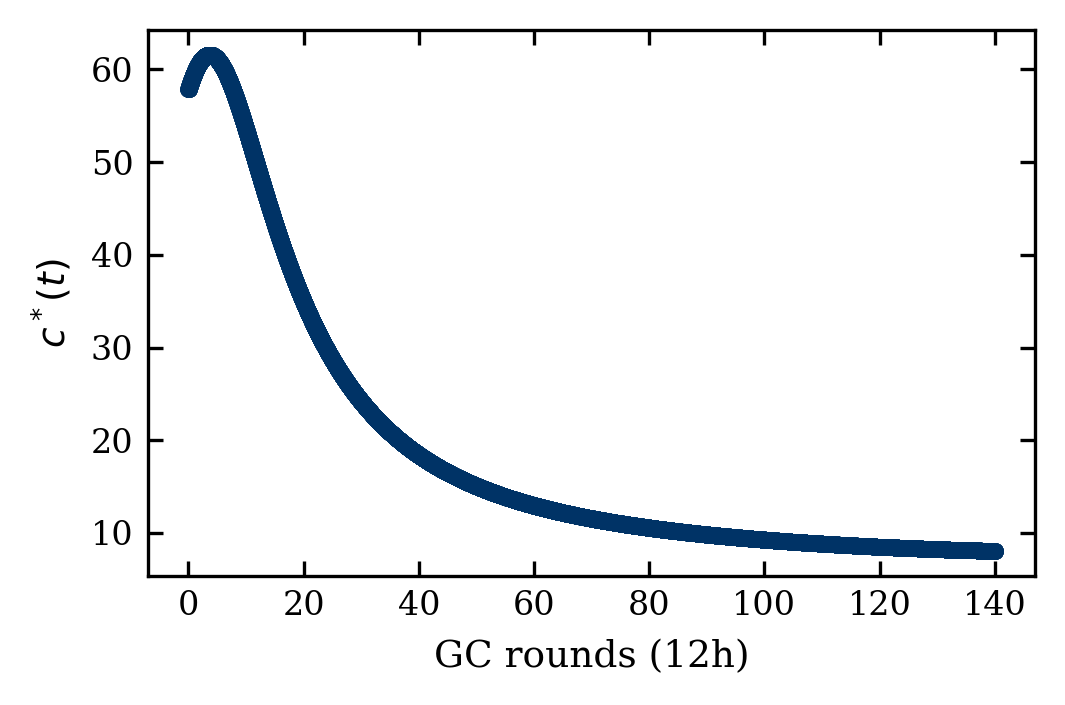

In [9]:
import matplotlib.pyplot as plt

# 1. Apply the publication-ready formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 3,
    "figure.figsize": (3.4, 2.2),  # Keeping your requested aspect ratio
    "figure.dpi": 300,
    "font.family": "serif",
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using the "Navy Blue" from the previous palette for consistency
ax.plot(times, c_star, 
        marker='o', 
        markersize=3, 
        linewidth=1.0, 
        color='#003366',  # Professional dark blue
        label=r"$c^*(t)$")

# 4. Set Labels
ax.set_xlabel(r"GC rounds (12h)")
ax.set_ylabel(r"$c^*(t)$")

# 5. Apply aesthetic preferences (ticks in, no grid)
ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# 6. Layout and Save
plt.tight_layout(pad=0.2)
# plt.savefig("c_star_vs_time.pdf")  # Uncomment to save
plt.show()


### Compute C* with multiple rounds of convergence

In [10]:
import numpy as np



def iterate_fp_and_cstar(initial_fp_ctx, num_iterations, T, lam, kBT, E_a):
    """
    Alternates between solving for the optimal concentration C*(t) and 
    running the Fokker-Planck solver to find the new trajectory/distribution.
    """
    c_star_history = []
    fp_ctx = initial_fp_ctx
    
    for i in range(num_iterations):
        # 1. Obtain optimal concentration from the current FP context
        times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a)
        
        # Save the result for plotting convergence later
        c_star_history.append((times.copy(), c_star.copy()))
        
        print(f"Iteration {i+1}/{num_iterations} complete.")
        
        # 2. Create the interpolation function for the next FP run
        get_C_star = make_get_C_from_cstar(times, c_star)
        
        # 3. Run the Fokker-Planck solver with the updated concentration profile
        fp_ctx = run_fp(
            get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h1 and h2
            get_C=get_C_star,
            T=T,
            verbose=False
        )
        
    return c_star_history, fp_ctx

# Example usage:
num_iterations = 5
fp_ctx_init = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)
c_star_history, fp_ctx_star = iterate_fp_and_cstar(fp_ctx_init, num_iterations, T=T, lam=lam, kBT=kBT, E_a=E_a)
#plot



Iteration 1/5 complete.
Iteration 2/5 complete.
Iteration 3/5 complete.
Iteration 4/5 complete.
Iteration 5/5 complete.


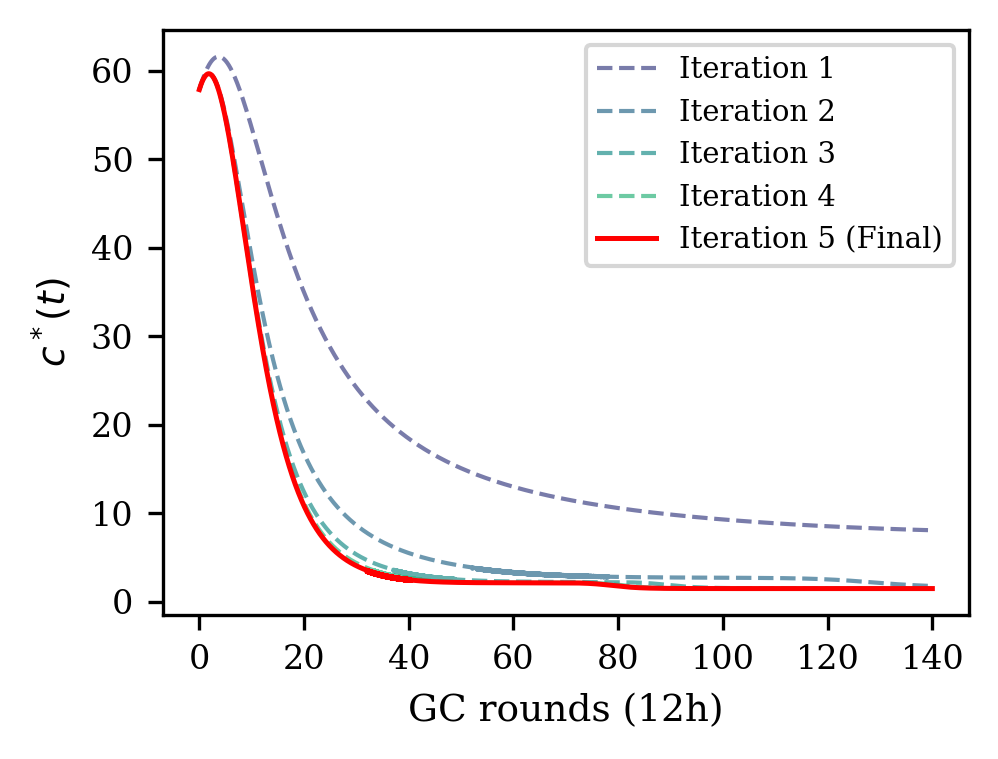

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_c_star_convergence(c_star_history):
    """Generates a plot showing the convergence of optimal concentration c*(t)."""
    
    # Global Style Settings
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.markersize": 3,
        "figure.figsize": (3.4, 2.6), # Standard column width
        "figure.dpi": 300,
        "font.family": "serif",
    })

    fig, ax = plt.subplots()
    
    num_iters = len(c_star_history)
    # Generate a sequence of colors to visualize progression
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_iters))
    
    for i, (times, c_star) in enumerate(c_star_history):
        # Visually distinct styling for the final convergence iteration
        if i == num_iters - 1:
            ax.plot(times, c_star, color='red', marker='', linestyle='-', 
                    linewidth=1.2, label=f"Iteration {i+1} (Final)", zorder=3)
        else:
            # Intermediate iterations fade from dark to light
            ax.plot(times, c_star, color=colors[i], marker='', linestyle='--', 
                    linewidth=1.0, alpha=0.7, label=f"Iteration {i+1}", zorder=2)

    ax.set_xlabel(r"GC rounds (12h)")
    ax.set_ylabel(r"$c^*(t)$")
    
    # Optional styling adjustments based on your reference
    # ax.tick_params(direction="in", top=True, right=True)
    ax.grid(False)
    
    # Prevent legend clutter if there are many iterations
    if num_iters <= 5:
        ax.legend(frameon=True, loc='best', fontsize=7)
    else:
        # Show first, middle, and last iteration in legend
        handles, labels = ax.get_legend_handles_labels()
        display_indices = [0, num_iters // 2, -1]
        ax.legend([handles[j] for j in display_indices], 
                  [labels[j] for j in display_indices], 
                  frameon=True, loc='best', fontsize=7)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_c_star_convergence(c_star_history)
c_star=c_star_history[-1][1]


### Study the effect of c on the optimal schedule and optimal antigen

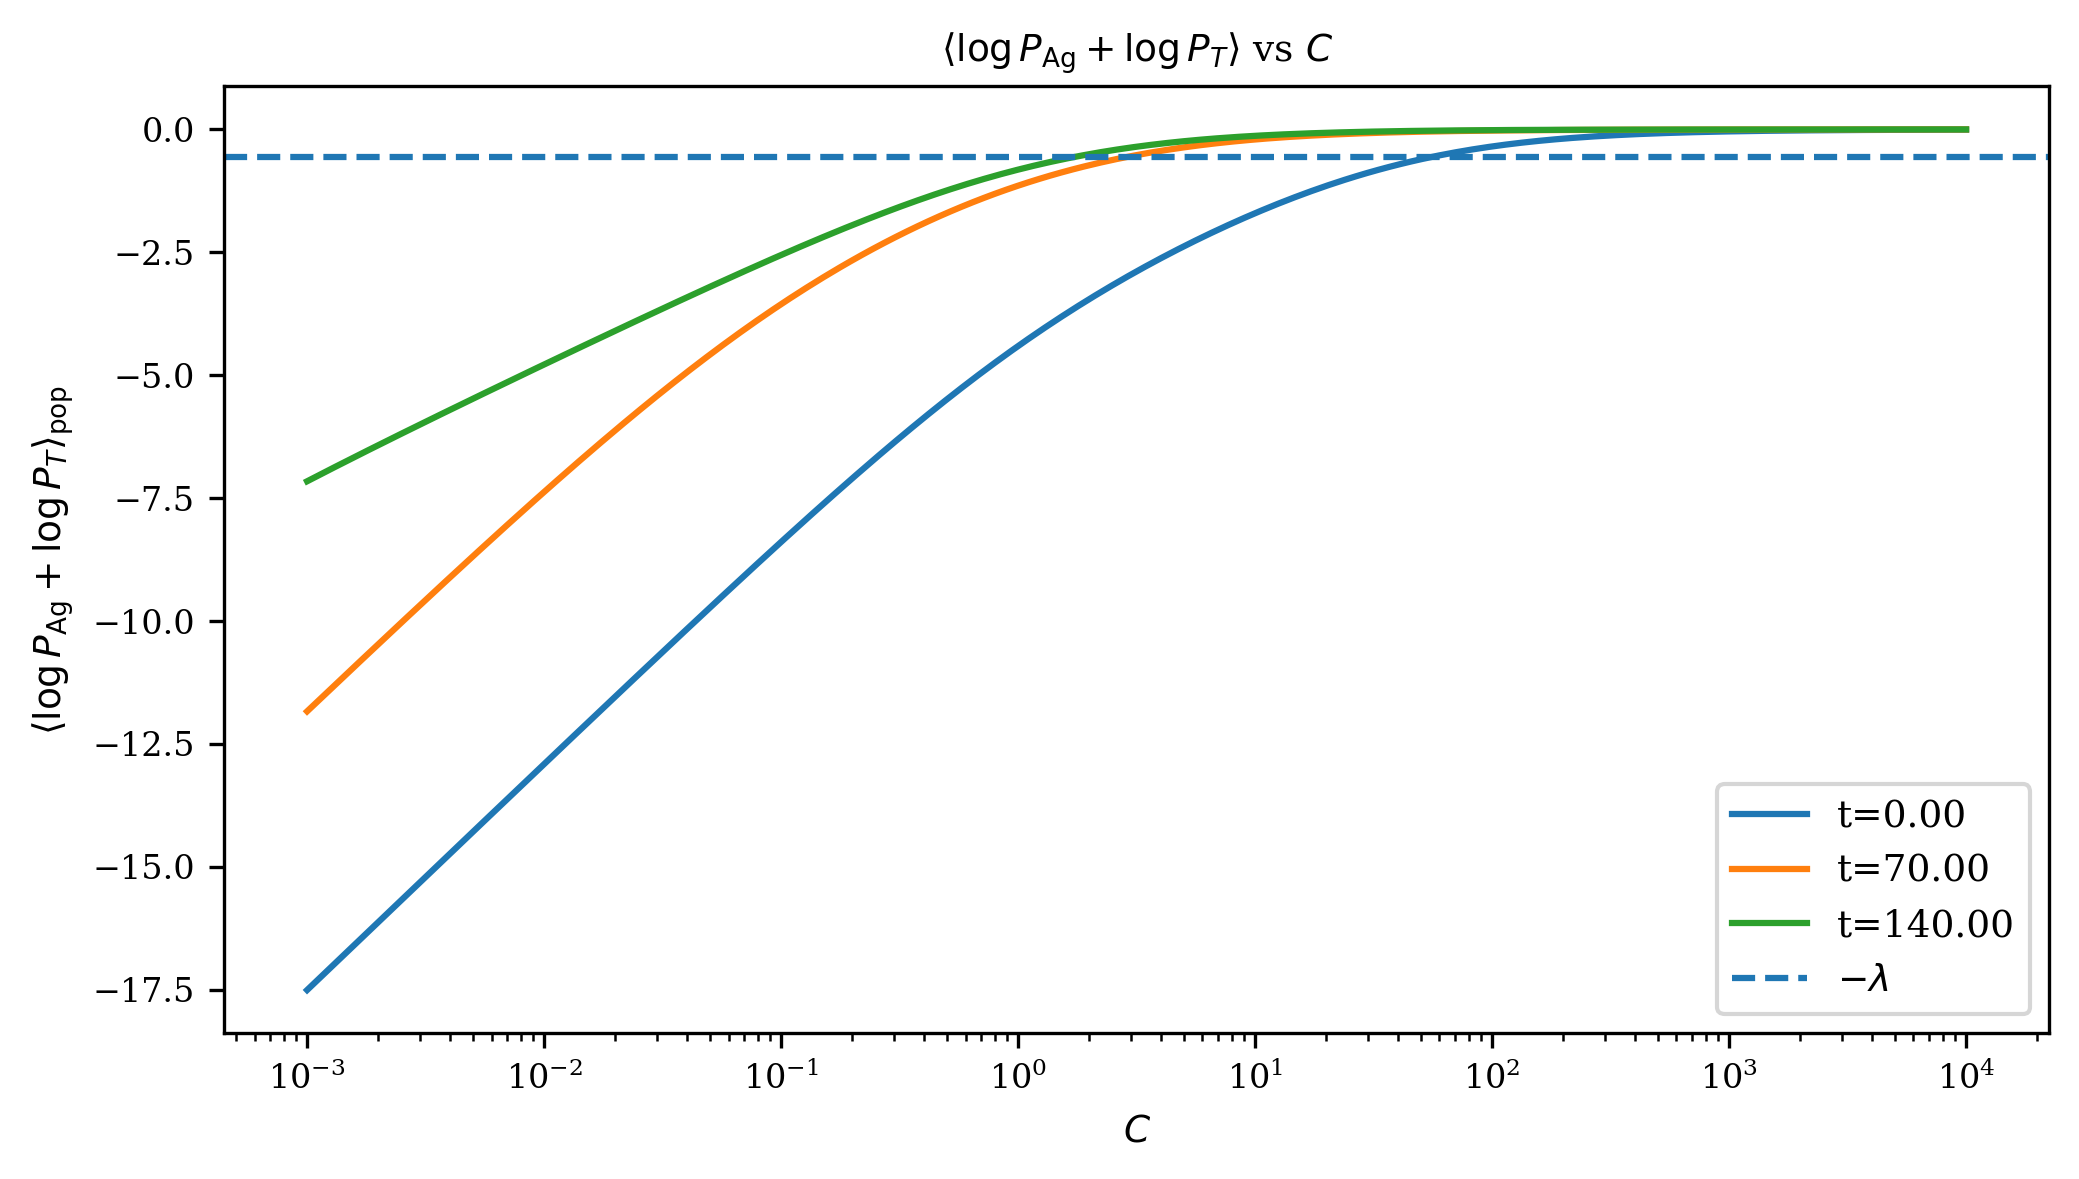

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    return axes, h_mesh, dH

def _E_stack_at_k(fp_ctx, k, h_mesh):
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]         # t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))  # (N_h, n_A)
    return np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))  # (n_A, ...)

def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop and (P_Ag + P_T)_pop at snapshot k,
    assuming all antigens have the same concentration C (scalar).
    """
    _, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)                        # (...)

    # P_T  (uses Phi_bar computed from current rho and S(t_k), independent of C)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop
    Phi_bar   = (w_pop * Phi).sum() * dH                     # scalar for this k
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    return float(avg_log), float(P_sum_pop)

# ---------- vectorized sweep over C for chosen snapshots ----------
def avg_log_vs_C_for_k(fp_ctx, k, C_grid, *, kBT, E_a):
    vals = np.empty_like(C_grid, dtype=float)
    for i, C in enumerate(C_grid):
        vals[i] = avg_log_terms_given_C(C, k, fp_ctx, kBT=kBT, E_a=E_a)[0]
    return vals

def plot_avg_log_vs_C(fp_ctx, k_list, *, kBT, E_a, lam=None,
                      C_min=1e-1, C_max=1e4, nC=200, logx=True,
                      title=r"$\langle \log P_{\mathrm{Ag}} + \log P_T \rangle$ vs $C$"):
    C_grid = np.logspace(np.log10(C_min), np.log10(C_max), nC) if logx else np.linspace(C_min, C_max, nC)
    plt.figure(figsize=(7, 4))
    for k in k_list:
        vals = avg_log_vs_C_for_k(fp_ctx, k, C_grid, kBT=kBT, E_a=E_a)
        t = float(fp_ctx["times"][k])
        plt.plot(C_grid, vals, label=f"t={t:.2f}")
    if lam is not None:
        plt.axhline(-lam, linestyle="--", label=r"$-\lambda$")
    if logx:
        plt.xscale("log")
    plt.xlabel(r"$C$")
    plt.ylabel(r"$\langle \log P_{\mathrm{Ag}} + \log P_T \rangle_{\text{pop}}$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
# choose a few snapshot indices to visualize, e.g. first, middle, last:
K = len(fp_ctx["times"])
k_list = [0, K//2, K-1]

plot_avg_log_vs_C(fp_ctx, k_list, kBT=kBT, E_a=E_a, lam=lam,
                  C_min=1e-3, C_max=1e4, nC=300, logx=True)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper Functions ---
def safe_log(x, eps=1e-12):
    return np.log(np.maximum(x, eps))

def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    return axes, h_mesh, dH

def _E_stack_at_k(fp_ctx, k, h_mesh):
    times = fp_ctx["times"]
    if "get_S" in fp_ctx:
        S_k = fp_ctx["get_S"](float(times[k]))
    else:
        S_k = fp_ctx["S_mat"]
    return np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0)), S_k

def _coerce_h_vec(h, N_h):
    if np.isscalar(h):
        vec = np.zeros(N_h, dtype=float); vec[0] = float(h); return vec
    h_arr = np.asarray(h, dtype=float).ravel()
    if h_arr.size == N_h:
        return h_arr
    if h_arr.size < N_h:
        vec = np.zeros(N_h, dtype=float); vec[:h_arr.size] = h_arr; return vec
    return h_arr[:N_h]

# --- 1. Calculation Function ---
def calculate_gamma_omega(fp_ctx_final, h_vals, C_values, *,
                          kBT, E_a, lam, N_max,
                          t_index=None, t_time=70):
    """
    Computes Gamma and Omega curves. 
    Returns a dictionary containing all computed arrays and key scalar values.
    """
    # Grid and Time Setup
    axes, h_mesh, dH = _grid_measures(fp_ctx_final)
    times = np.asarray(fp_ctx_final["times"], dtype=float)

    if t_index is not None:
        k = int(t_index)
    elif t_time is not None:
        k = int(np.argmin(np.abs(times - float(t_time)))) 
    else:
        k = len(times) - 1

    rho_f = fp_ctx_final["rho_t"][k]
    E_stack, S_final = _E_stack_at_k(fp_ctx_final, k, h_mesh)
    N_h, n_A = S_final.shape

    # Precompute population integrals
    Phi_grid = np.exp(E_stack / kBT).sum(axis=0)
    N_pop   = rho_f.sum() * dH
    w_pop   = rho_f / N_pop
    Phi_bar = (w_pop * Phi_grid).sum() * dH

    # Storage for results
    results = {
        "C": C_values,
        "gamma": {},  # Will store gamma array for each h
        "omega": None,
        "C0": None,   # First C where Omega > 0
        "lambda": lam,
        "max_gamma_locs": {} # Store max (C, Gamma) for each h
    }

    # Calculate Omega (Global) and Gamma (per h)
    # Note: Omega is independent of the specific h we probe, 
    # but we need to loop C to calculate it.
    
    omega_vals = []
    
    # We loop C once to compute Omega and store intermediate grids if needed,
    # or just compute Omega "on the fly" inside the h loop? 
    # Better to compute Omega once since it depends on the population distribution (w_pop).
    
    for C in C_values:
        C = float(C)
        C_tot = C * n_A
        
        # Omega Calculation
        exp_term_grid = np.exp((E_stack - E_a) / kBT)
        numer_grid    = (C * exp_term_grid).sum(axis=0)
        PAg_grid      = numer_grid / (1.0 + numer_grid)
        PT_grid       = Phi_grid / (Phi_grid + Phi_bar / C_tot)

        avg_log = (w_pop * (safe_log(PAg_grid) + safe_log(PT_grid))).sum() * dH
        Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)
        omega_vals.append(Omega)

    omega_vals = np.array(omega_vals)
    results["omega"] = omega_vals

    # Find C0 (First C where Omega > 0)
    idx_positive = np.where(omega_vals > 0)[0]
    if len(idx_positive) > 0:
        results["C0"] = C_values[idx_positive[0]]

    # Compute Gamma for each requested h
    for h in h_vals:
        h_vec = _coerce_h_vec(h, N_h)
        E_pt  = (S_final.T @ h_vec).ravel()
        Phi_pt = np.exp(E_pt / kBT).sum()
        exp_Es_pt = np.exp((E_pt - E_a) / kBT)

        g_vals = []
        for i, C in enumerate(C_values):
            C = float(C)
            C_tot = C * n_A
            Omega = omega_vals[i] # Reuse precalculated Omega

            numer_pt = (C * exp_Es_pt).sum()
            PAg_pt   = numer_pt / (1.0 + numer_pt)
            PT_pt    = Phi_pt / (Phi_pt + Phi_bar / C_tot)

            gamma_pt = lam + safe_log(PAg_pt) + safe_log(PT_pt) - Omega
            g_vals.append(gamma_pt)
        
        g_vals = np.array(g_vals)
        results["gamma"][h] = g_vals
        
        # Find Max Gamma location
        max_idx = np.argmax(g_vals)
        results["max_gamma_locs"][h] = (C_values[max_idx], g_vals[max_idx])

    return results


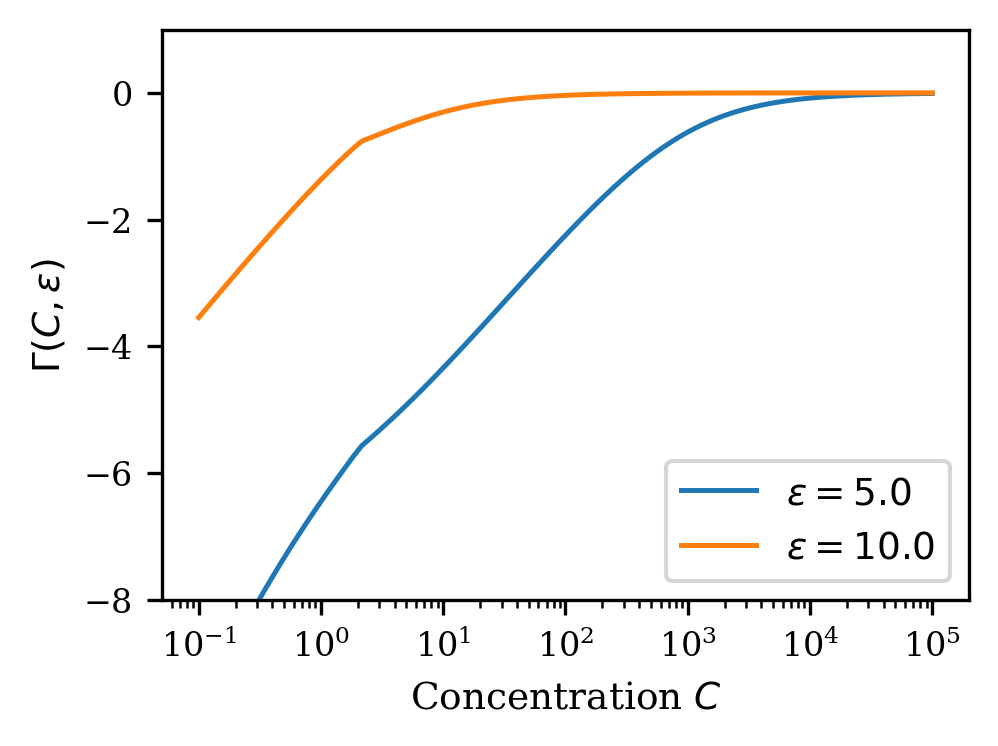

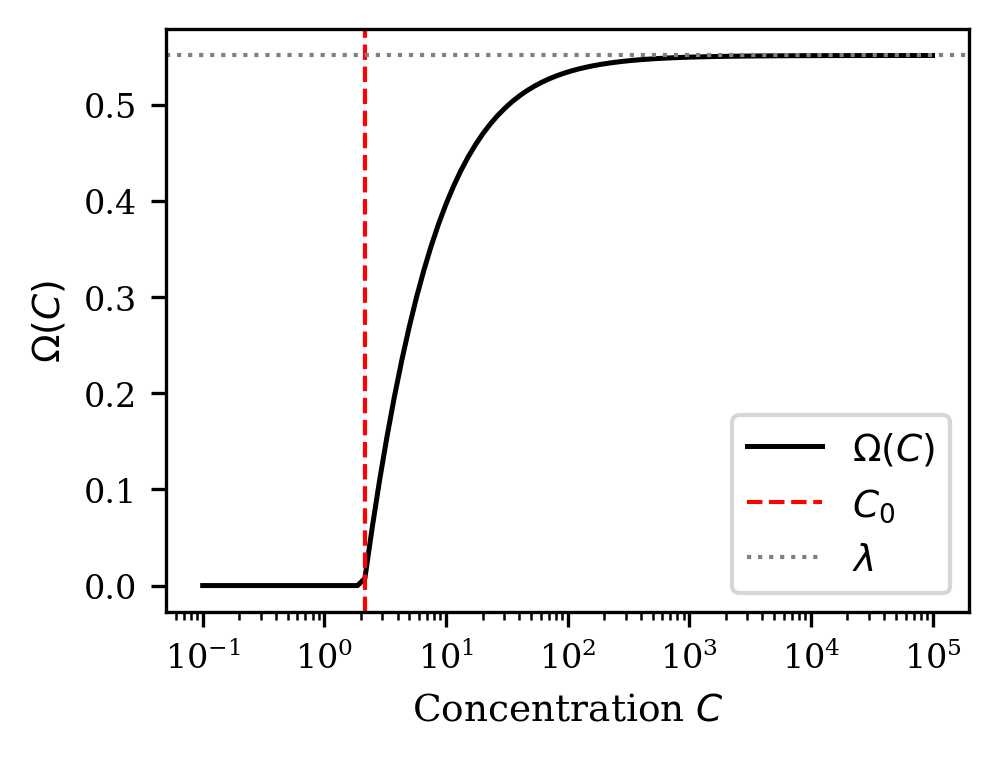

In [14]:

# =========================================================
# 2. Execution & Plotting Phase
# =========================================================

# --- A. Run Calculation ---
# Assuming 'fp_ctx_opt' or similar is your final context variable
# and parameters are defined in your environment.

# Example placeholder call (Uncomment/Modify with your actual variables)
data = calculate_gamma_omega(fp_ctx_star, 
                             h_vals=[5.0, 10.0], 
                             C_values=np.logspace(-1, 5, 100),
                             kBT=kBT, E_a=E_a, lam=lam, N_max=N_max)

# --- B. Plotting Script ---

def plot_gamma_omega(data):
    """Generates two separate plots from the calculated data."""
    
    # Global Style Settings
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.markersize": 4,
        "figure.figsize": (3.4, 2.6), # Standard column width
        "figure.dpi": 300,
        "font.family": "serif",
    })

    # ---------------- FIGURE 1: Gamma vs C ----------------
    fig1, ax1 = plt.subplots()
    
    for h, g_vals in data["gamma"].items():
        # Plot curve
        line, = ax1.plot(data["C"], g_vals, label=rf"$\epsilon={h}$", linewidth=1.2)
        
        # Add vertical drop line for max
        max_C, max_val = data["max_gamma_locs"][h]
        if max_C<1000:

            ax1.vlines(x=max_C, ymin=-15, ymax=max_val, 
                    colors='red', linestyles='--', linewidth=1.0, alpha=0.7, label=r"$C_0$")

    ax1.set_xscale("log")
    ax1.set_xlabel(r"Concentration $C$")
    ax1.set_ylabel(r"$\Gamma(C,\epsilon)$")
    ax1.set_ylim(-8, 1) # Adjust as needed
    
    # ax1.tick_params(direction="in", top=True, right=True)
    ax1.grid(False)
    ax1.legend(frameon=True, loc='best')
    
    plt.tight_layout()
    plt.show() # Or fig1.savefig("gamma_plot.pdf")

    # ---------------- FIGURE 2: Omega vs C ----------------
    fig2, ax2 = plt.subplots()
    
    # 1. Plot Omega Curve
    ax2.plot(data["C"], data["omega"], color='black', linestyle='-', linewidth=1.2, label=r"$\Omega(C)$")
    
    # 2. Plot C0 (Vertical Line)
    if data["C0"] is not None:
        ax2.axvline(x=data["C0"], color='red', linestyle='--', linewidth=1.0, 
                    label=r"$C_0$")
        
    # 3. Plot Lambda (Horizontal Asymptote)
    lam_val = data["lambda"]
    ax2.axhline(y=lam_val, color='gray', linestyle=':', linewidth=1.0, 
                label=r"$\lambda$")

    ax2.set_xscale("log")
    ax2.set_xlabel(r"Concentration $C$")
    ax2.set_ylabel(r"$\Omega(C)$")
    # ax2.set_ylim(bottom=-0.1) # Optional: constrain y-view
    
    # ax2.tick_params(direction="in", top=True, right=True)
    ax2.grid(False)
    ax2.legend(frameon=True, loc='best')
    
    plt.tight_layout()
    plt.show() # Or fig2.savefig("omega_plot.pdf")

# Example usage:
plot_gamma_omega(data)

# Injection optim

In [15]:
times.shape#(28001,)
c_star.shape#(28001,)
#save as a csv
import pandas as pd

df = pd.DataFrame({"time": times, "c_star": c_star})
df.to_csv("c_star_over_time.csv", index=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ImmunizationOptimizer(nn.Module):
    def __init__(self, N, tau, initial_C_values, initial_interval_values):
        super().__init__()
        self.N = N
        self.tau = float(tau)
        
        # Helper for inverse softplus: x = ln(exp(y) - 1)
        def inverse_softplus(y):
            return np.log(np.exp(y) + 1e-6 - 1)

        # 1. Parameter for Concentrations (C_i)
        init_C_raw = [inverse_softplus(val) for val in initial_C_values]
        self.raw_C = nn.Parameter(torch.tensor(init_C_raw, dtype=torch.float32))
        
        # 2. Parameter for Time Intervals (dt)
        if N > 1:
            init_dt_raw = [inverse_softplus(val) for val in initial_interval_values]
            self.raw_dt = nn.Parameter(torch.tensor(init_dt_raw, dtype=torch.float32))
        else:
            self.raw_dt = None

    def get_physical_parameters(self):
        # Ensure Positive Concentrations
        C_i = torch.nn.functional.softplus(self.raw_C)
        
        # Construct Times from Intervals
        t_1 = torch.tensor([0.0], device=self.raw_C.device)
        if self.N > 1:
            intervals = torch.nn.functional.softplus(self.raw_dt)
            later_times = torch.cumsum(intervals, dim=0)
            t_i = torch.cat([t_1, later_times])
        else:
            t_i = t_1
            
        return C_i, t_i

    def forward(self, t_eval, sigmoid_steepness=50.0):
        C_i, t_i = self.get_physical_parameters()
        
        t_eval = t_eval.view(-1, 1)
        t_i = t_i.view(1, -1)
        C_i = C_i.view(1, -1)
        
        dt = t_eval - t_i
        
        # Differentiable Step Function
        step_approx = torch.sigmoid(sigmoid_steepness * dt)
        
        # FIX: Use ReLU to prevent exponential explosion for t < t_i
        # It forces the decay term to 1.0 before the injection, which is then 
        # safely zeroed out by the step_approx multiplier.
        safe_dt = torch.relu(dt)
        decay = torch.exp(-safe_dt / self.tau)
        
        concentration_matrix = step_approx * C_i * decay
        C_total = torch.sum(concentration_matrix, dim=1)
        
        return C_total

def find_optimal_parameters(N, tau, t_eval_array, C_star_array, epochs=2000, lr=0.1):
    init_intervals = [20.0] * (N - 1)
    init_C_values = []
    
    for i in range(N):
        expected_time = i * 20.0
        idx = (np.abs(t_eval_array - expected_time)).argmin()
        val = max(float(C_star_array[idx]), 1e-4)
        init_C_values.append(val)

    t_tensor = torch.tensor(t_eval_array, dtype=torch.float32)
    C_star_tensor = torch.tensor(C_star_array, dtype=torch.float32)
    
    model = ImmunizationOptimizer(N, tau, init_C_values, init_intervals)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Annealing
        current_steepness = 10.0 + (90.0 * epoch / epochs)
        
        C_simulated = model(t_tensor, sigmoid_steepness=current_steepness)
        
        # Compute Loss
        # loss = loss_fn(torch.log(C_simulated + 1e-8), torch.log(C_star_tensor + 1e-8))
        loss = loss_fn(torch.log(C_simulated + 1e-8), torch.log(C_star_tensor + 1e-8))

        loss.backward()
        optimizer.step()

    final_C, final_t = model.get_physical_parameters()
    
    return {
        "C_optimized": final_C.detach().numpy(),
        "t_optimized": final_t.detach().numpy(),
        "final_loss": loss.item(),
        'C_simulated': C_simulated.detach().numpy()
    }
N_injections = 3
tau_val = 20.0

result = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result['C_optimized'])
print("Optimized Times (t):", result['t_optimized'])


Final Result:
Optimized Injections (C): [32.443226   3.2057142  2.7720342]
Optimized Times (t): [  0.        68.464325 106.48348 ]


In [49]:
N_injections = 1
tau_val = 20.0

result2 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result2['C_optimized'])
print("Optimized Times (t):", result2['t_optimized'])


Final Result:
Optimized Injections (C): [98.83043]
Optimized Times (t): [0.]


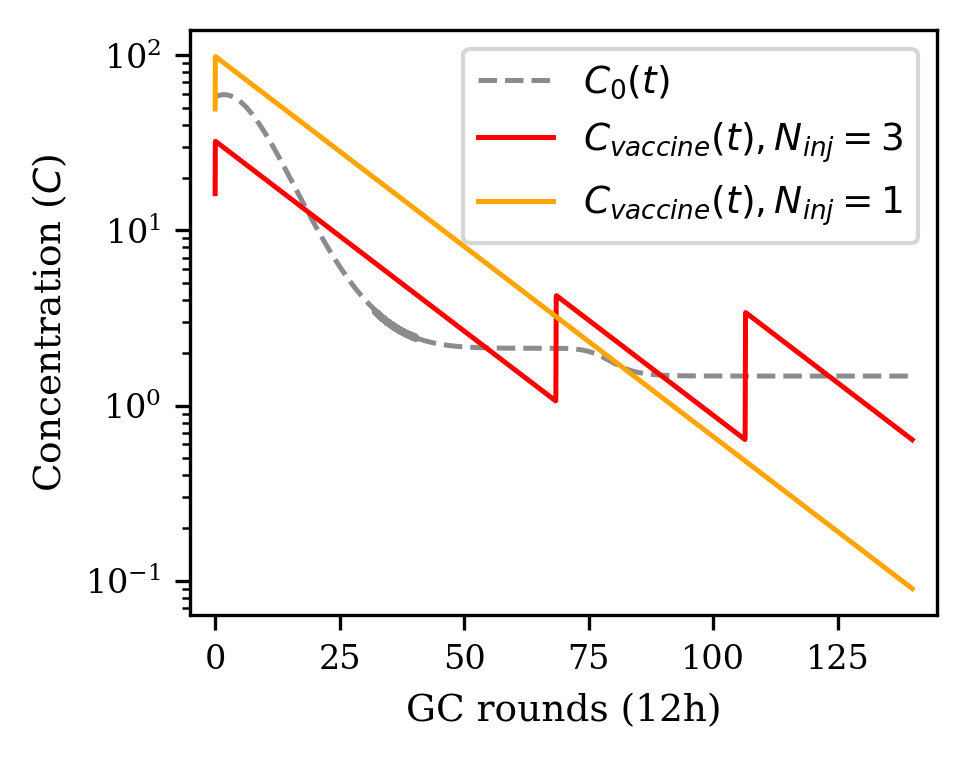

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Setup Plotting Style (Matching your template)
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

# ---------------------------------------------------------
# 2. Extract Data from Optimization Result
# ---------------------------------------------------------
# Assuming 'result' dictionary is available from the previous step
# and 't_data' and 'C_target' are the original inputs.

t_sim = times                 # Time axis
C_sim = result['C_simulated'].flatten() # Simulated Response
C_ref = c_star               # Target C_star

t_inj = result['t_optimized']  # Injection times
C_inj = result['C_optimized']  # Injection doses (optional to visualize)

t_inj2 = result2['t_optimized']  # Injection times
C_inj2 = result2['C_optimized']  # Injection doses (optional to visualize)
C_sim2 = result2['C_simulated'].flatten() # Simulated Response

# ---------------------------------------------------------
# 3. Create Figure and Axes
# ---------------------------------------------------------
fig, ax = plt.subplots()

# ---------------------------------------------------------
# 4. Plot the Curves
# ---------------------------------------------------------

# Target C* (Dashed, Lighter Blue)
ax.plot(t_sim, C_ref, 
        label=r"$C_0(t)$", 
        color='grey',       # Soft Blue
        linestyle='--', 
        linewidth=1.2,
        alpha=0.9)

# Simulated C (Solid, Darker/Rich Blue)
ax.plot(t_sim, C_sim, 
        label=r"$C_{vaccine}(t), N_{inj}=3$",
        color='red',       # Navy Blue
        linestyle='-', 
        linewidth=1.2)

ax.plot(t_sim, C_sim2, 
        label=r"$C_{vaccine}(t), N_{inj}=1$",
        color='orange',       # Navy Blue
        linestyle='-', 
        linewidth=1.2)


# ---------------------------------------------------------
# 5. Add Injection Lines
# ---------------------------------------------------------
# Loop to plot lines, but only add label to legend once
# for i, t_val in enumerate(t_inj):
#     label = "Injection" if i == 0 else None
#     ax.axvline(x=t_val, 
#                color='black', # Nice Red
#                linestyle=':', 
#                linewidth=1.0, 
#                label=label)

# Optional: Add small triangles at the top to emphasize injection timing
# ax.plot(t_inj, [ax.get_ylim()[1]]*len(t_inj), 
#         marker='v', color='#D0021B', linestyle='None', markersize=3, clip_on=False)

# ---------------------------------------------------------
# 6. Formatting & Labels
# ---------------------------------------------------------
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Concentration ($C$)")
ax.set_xlim(t_sim[0], t_sim[-1])
# ax.set_ylim(bottom=0)  # Concentration cannot be negative
plt.yscale("log")  # Log scale for better visibility of differences

# Ticks pointing inwards (Your preference)
# ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# Legend (No frame, best location)
ax.legend(frameon=True, loc='best')

# ---------------------------------------------------------
# 7. Final Output
# ---------------------------------------------------------
fig.tight_layout()
plt.xlim(-5, 145)

plt.show()

# Optional: Save
# fig.savefig("optimization_result.pdf", format='pdf', bbox_inches='tight')

In [64]:
get_C_star_vacc = make_get_C_from_cstar(times, C_sim)
get_C_star_vacc2 = make_get_C_from_cstar(times, C_sim2)

#save as csv
df_vacc = pd.DataFrame({"time": times, "C_vaccine_Ninj3": C_sim, "C_vaccine_Ninj1": C_sim2})
df_vacc.to_csv("optimized_vaccine_concentration.csv", index=False)


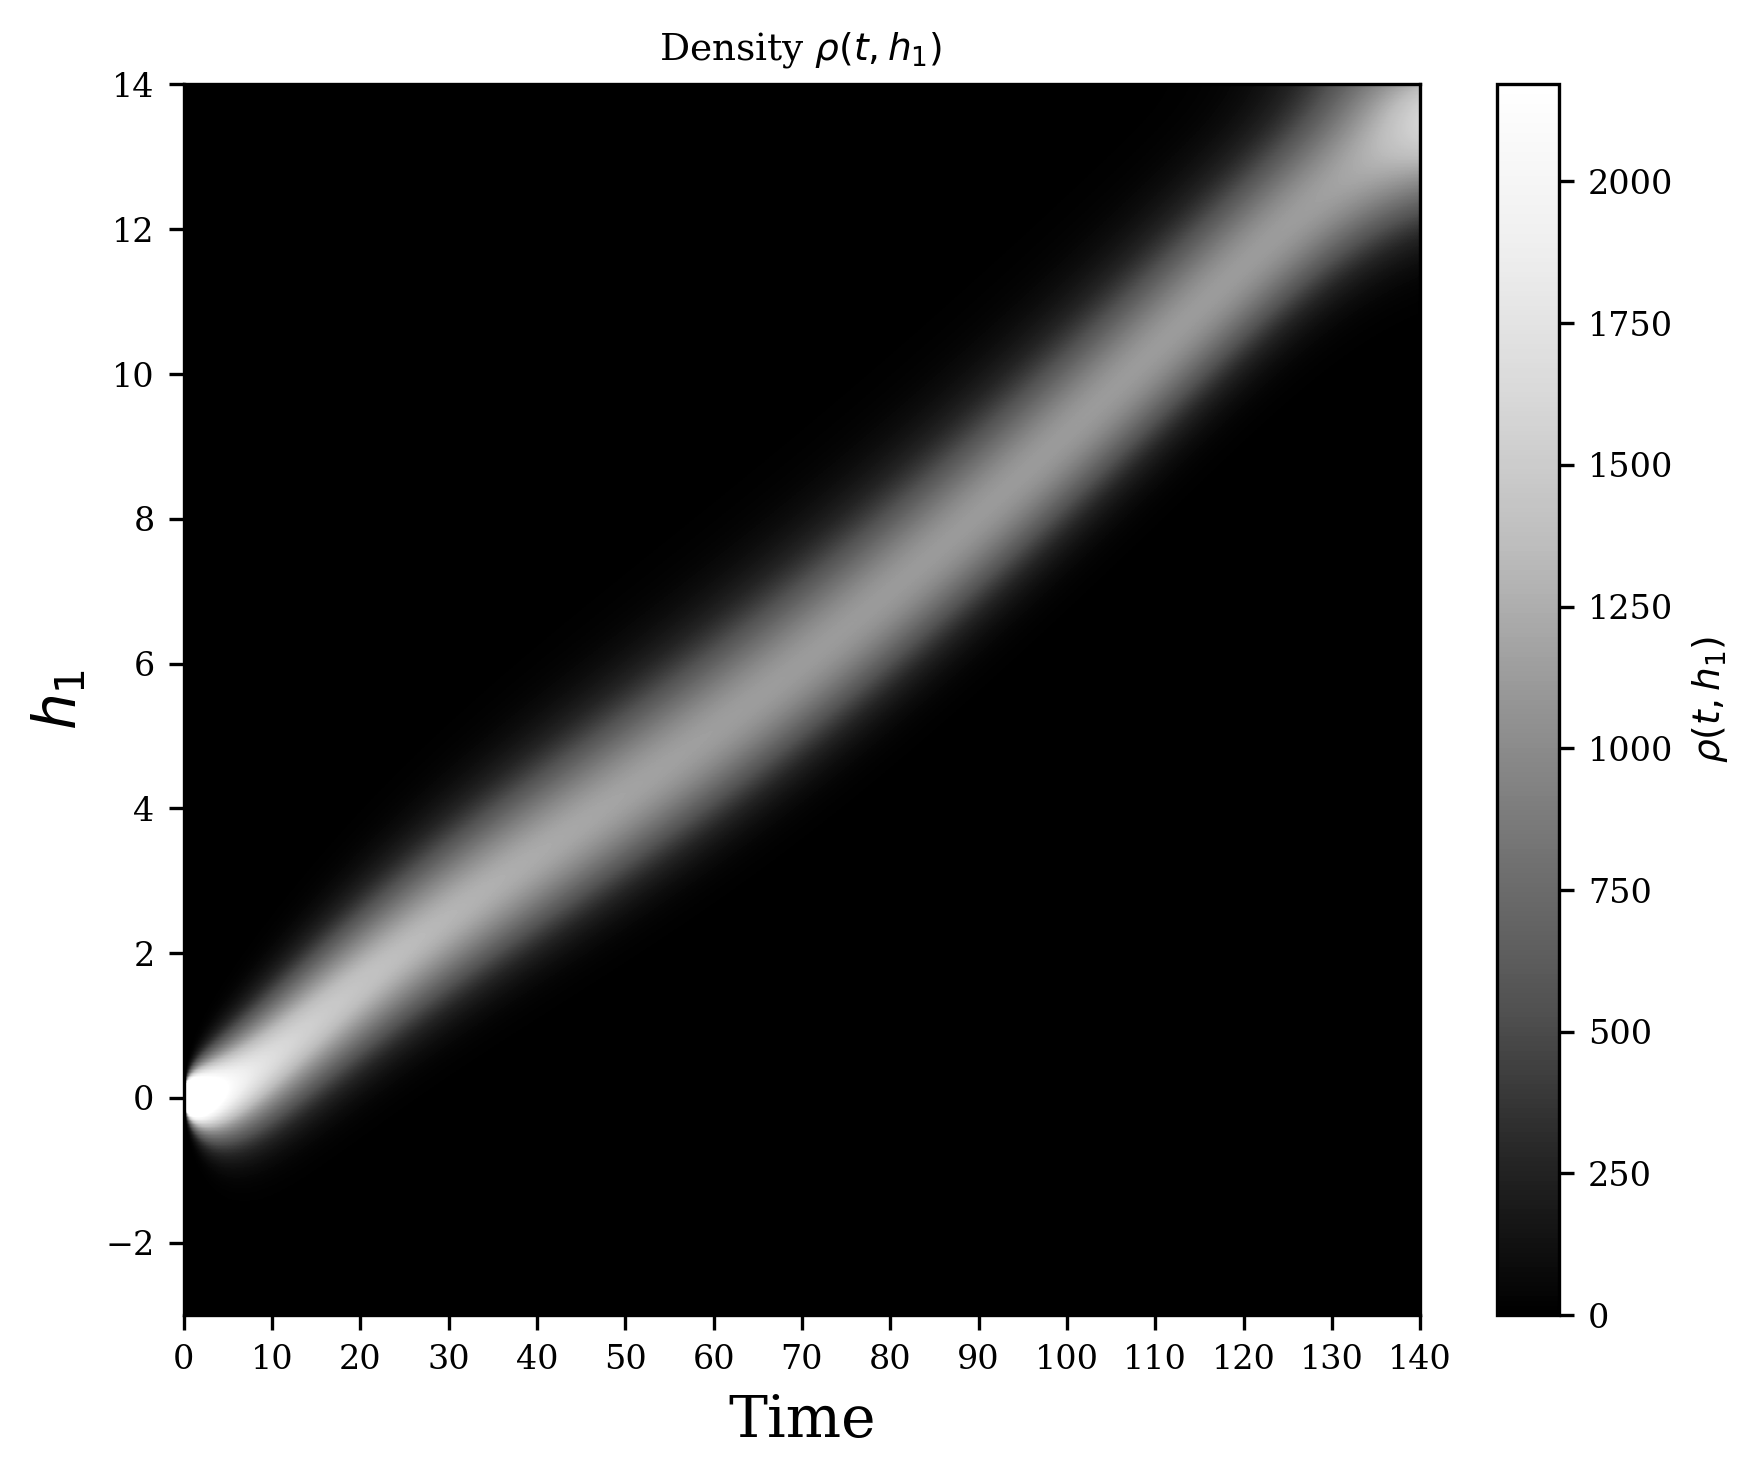

In [52]:
fp_ctx_opt = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)

#plot
plot_fp_density_time_dim(fp_ctx_opt, sol=None, disp_step=10, cmap="Greys_r")

In [53]:


fp_ctx_mean = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:C_ref.mean(),
    T=T,
    verbose=False
)

fp_ctx_fixed = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:170,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc2 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc2,
    T=T,
    verbose=False
)


In [54]:
def _marginal_h1_pdf(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the LAST snapshot in fp_ctx where 
    the population has at least 2000 individuals. Works for N_h >= 1 
    by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element
    dH = d_h ** N_h

    # Iterate backwards through time to find the correct snapshot
    rho_stack = fp_ctx["rho_t"]
    rho_alive = rho_stack[0]            # Fallback to initial state
    
    for i in range(len(rho_stack) - 1, -1, -1):
        current_population = rho_stack[i].sum() * dH
        if current_population >= 1250: 
            rho_alive = rho_stack[i]
            print(f"Selected snapshot index: {i}, Population: {current_population:.2f}")
            break

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

In [55]:
def _marginal_h1_pdf(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the LAST snapshot in fp_ctx where 
    the population has at least 2000 individuals. Works for N_h >= 1 
    by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element
    dH = d_h ** N_h

    # Iterate backwards through time to find the correct snapshot
    rho_stack = fp_ctx["rho_t"]
    rho_alive = rho_stack[0]            # Fallback to initial state
    
    for i in range(len(rho_stack) - 1, -1, -1):
        current_population = rho_stack[i].sum() * dH
        if current_population >= 1250: 
            rho_alive = rho_stack[i]
            print(f"Selected snapshot index: {i}, Population: {current_population:.2f}")
            break

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

In [56]:
def _marginal_last(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the snapshot in fp_ctx where 
    the total density above h_c is maximized. Works for N_h >= 1 
    by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element

    rho_stack = fp_ctx["rho_t"]
    
    # Boolean mask for the region strictly above h_c on the h1 axis
    
    best_index = -1
    
 

    # Select the snapshot with the maximum density above h_c
    rho_alive = rho_stack[best_index]

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

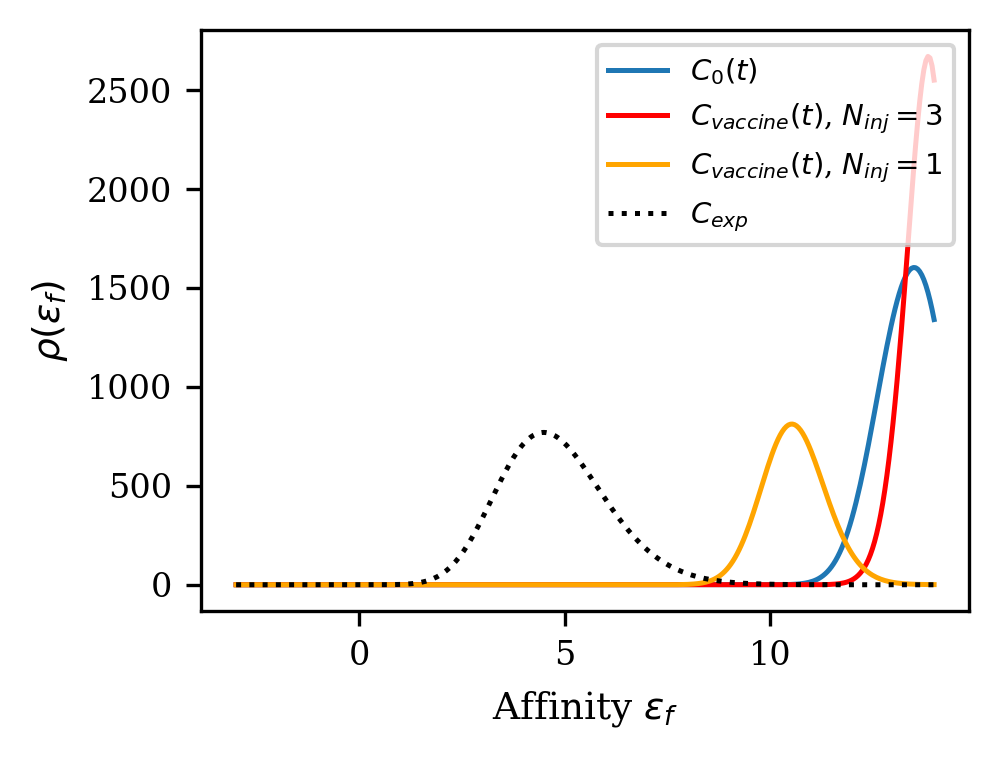

In [57]:

import numpy as np
import matplotlib.pyplot as plt


# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_h1_pdf_max_above_hc(fp_ctx_opt)

h1_mean,  pdf_mean  = _marginal_h1_pdf_max_above_hc(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_h1_pdf_max_above_hc(fp_ctx_fixed)
h1_opt_vacc, pdf_opt_vacc = _marginal_h1_pdf_max_above_hc(fp_ctx_opt_vacc)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_h1_pdf_max_above_hc(fp_ctx_opt_vacc2)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
import matplotlib.pyplot as plt

# 1. Apply your preferred formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using different linestyles helps distinguish curves in small/B&W figures
ax.plot(h1_opt,   pdf_opt,   label=r"$C_0(t)$",               linestyle='-',  linewidth=1.2)
# ax.plot(h1_mean,  pdf_mean,  label=r"$\langle C_0(t)\rangle_t$", linestyle='--', linewidth=1.2, color='blue')
ax.plot(h1_opt_vacc, pdf_opt_vacc, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='-',  linewidth=1.2, color='red')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-',  linewidth=1.2, color='orange')
ax.plot(h1_fixed, pdf_fixed, label=r"$C_{exp}$",                linestyle=':',  linewidth=1.2, color='black')

# 4. Set Limits and Labels
# ax.set_xlim(2, 14)
ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")
# ax.set_title(r"Marginal density of $h_1$")

# 5. Apply aesthetic preferences (ticks in, no grid)
# ax.tick_params(direction="in", top=True, right=True) # Added top/right ticks which usually accompany 'in'
ax.grid(False)

# 6. Legend and Layout
# frameon=False usually looks cleaner in small academic plots
ax.legend(frameon=True, loc='upper right', fontsize=7)

fig.tight_layout()
plt.show()



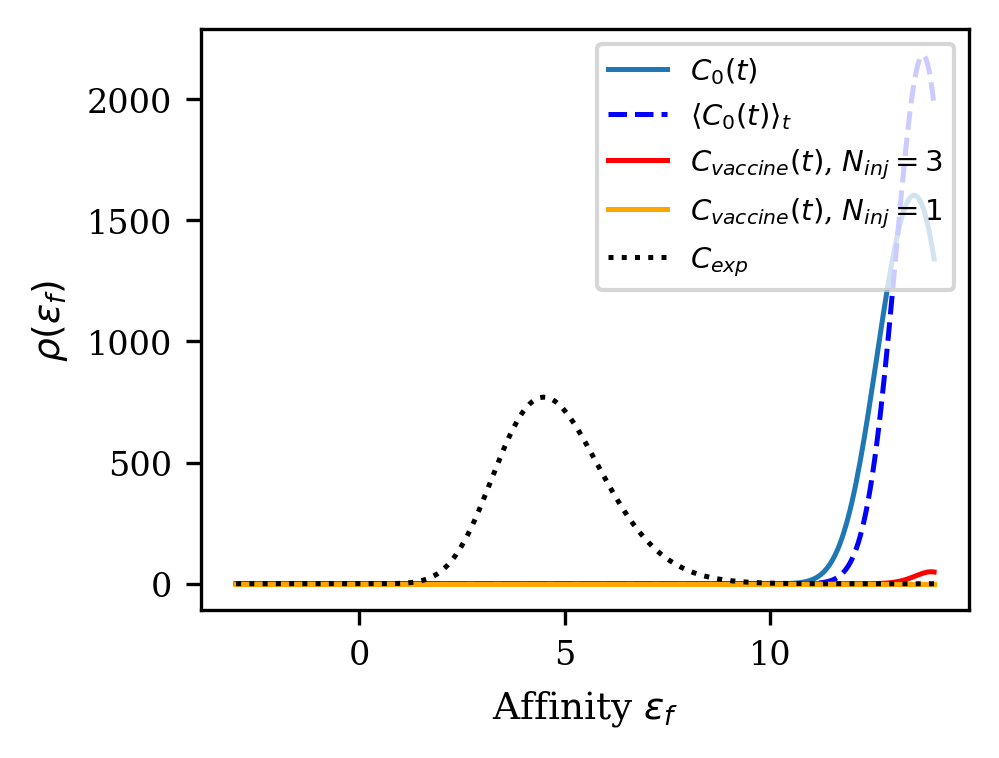

In [62]:

import numpy as np
import matplotlib.pyplot as plt


# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_last(fp_ctx_opt)

h1_mean,  pdf_mean  = _marginal_last(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_last(fp_ctx_fixed)
h1_opt_vacc, pdf_opt_vacc = _marginal_last(fp_ctx_opt_vacc)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_last(fp_ctx_opt_vacc2)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
import matplotlib.pyplot as plt

# 1. Apply your preferred formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using different linestyles helps distinguish curves in small/B&W figures
ax.plot(h1_opt,   pdf_opt,   label=r"$C_0(t)$",               linestyle='-',  linewidth=1.2)
ax.plot(h1_mean,  pdf_mean,  label=r"$\langle C_0(t)\rangle_t$", linestyle='--', linewidth=1.2, color='blue')
ax.plot(h1_opt_vacc, pdf_opt_vacc, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='-',  linewidth=1.2, color='red')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-',  linewidth=1.2, color='orange')
ax.plot(h1_fixed, pdf_fixed, label=r"$C_{exp}$",                linestyle=':',  linewidth=1.2, color='black')

# 4. Set Limits and Labels
# ax.set_xlim(2, 14)
ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")
# ax.set_title(r"Marginal density of $h_1$")

# 5. Apply aesthetic preferences (ticks in, no grid)
# ax.tick_params(direction="in", top=True, right=True) # Added top/right ticks which usually accompany 'in'
ax.grid(False)

# 6. Legend and Layout
# frameon=False usually looks cleaner in small academic plots
ax.legend(frameon=True, loc='upper right', fontsize=7)

fig.tight_layout()
plt.show()



Selected snapshot index: 28000, Population: 2500.10
Selected snapshot index: 28000, Population: 2500.80
Selected snapshot index: 28000, Population: 2500.83
Selected snapshot index: 19386, Population: 1250.47
Selected snapshot index: 16758, Population: 1250.01


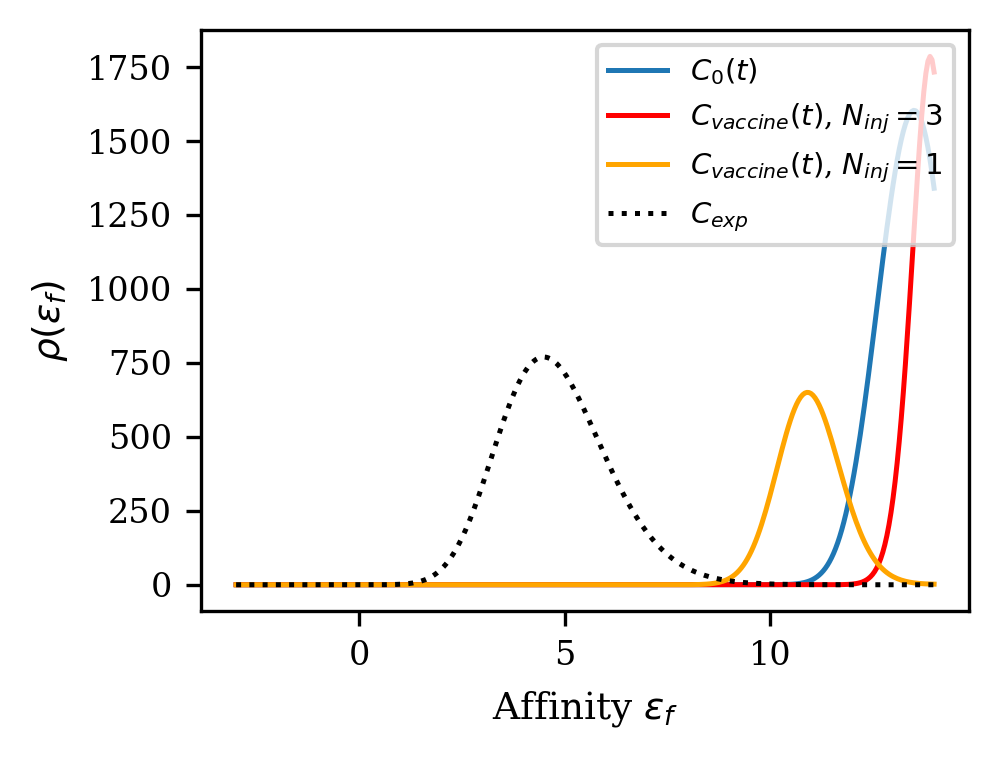

In [60]:

import numpy as np
import matplotlib.pyplot as plt


# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_h1_pdf(fp_ctx_opt)

h1_mean,  pdf_mean  = _marginal_h1_pdf(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_h1_pdf(fp_ctx_fixed)
h1_opt_vacc, pdf_opt_vacc = _marginal_h1_pdf(fp_ctx_opt_vacc)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_h1_pdf(fp_ctx_opt_vacc2)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
import matplotlib.pyplot as plt

# 1. Apply your preferred formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using different linestyles helps distinguish curves in small/B&W figures
ax.plot(h1_opt,   pdf_opt,   label=r"$C_0(t)$",               linestyle='-',  linewidth=1.2)
# ax.plot(h1_mean,  pdf_mean,  label=r"$\langle C_0(t)\rangle_t$", linestyle='--', linewidth=1.2, color='blue')
ax.plot(h1_opt_vacc, pdf_opt_vacc, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='-',  linewidth=1.2, color='red')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-',  linewidth=1.2, color='orange')
ax.plot(h1_fixed, pdf_fixed, label=r"$C_{exp}$",                linestyle=':',  linewidth=1.2, color='black')

# 4. Set Limits and Labels
# ax.set_xlim(2, 14)
ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")
# ax.set_title(r"Marginal density of $h_1$")

# 5. Apply aesthetic preferences (ticks in, no grid)
# ax.tick_params(direction="in", top=True, right=True) # Added top/right ticks which usually accompany 'in'
ax.grid(False)

# 6. Legend and Layout
# frameon=False usually looks cleaner in small academic plots
ax.legend(frameon=True, loc='upper right', fontsize=7)

fig.tight_layout()
plt.show()



In [61]:
import numpy as np

def calculate_density_above_hc(h1_axis, pdf, h_c):
    """
    Evaluate the total density for values strictly greater than h_c.
    
    Parameters:
    h1_axis (np.ndarray): 1D array of the h1 grid points.
    pdf (np.ndarray): 1D array of the marginal density.
    h_c (float): The threshold value.
    
    Returns:
    float: The integrated density above h_c.
    """
    # Create a boolean mask for the region of interest
    mask = h1_axis > h_c
    
    # Calculate the grid step size
    d_h = h1_axis[1] - h1_axis[0]
    
    # Integrate using a Riemann sum over the masked region
    total_density = pdf[mask].sum() * d_h
    
    return total_density

# Example usage within your workflow (data and context must be provided):
density_above_threshold = calculate_density_above_hc(h1_opt, pdf_opt, h_c=10)
print(f"Density above h_c=1.5 for optimized vaccine schedule: {density_above_threshold:.4f}")

Density above h_c=1.5 for optimized vaccine schedule: 2500.0892


# High affinity as a function of Tau and N_inj

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_inj_array = [1, 2, 3]
Tau_array = [10.0, 20.0, 30.0]

# Dictionary to store results mapped by number of injections
results = {n: [] for n in N_inj_array}

for N_injections in N_inj_array:
    for tau_val in Tau_array:
        
        result = find_optimal_parameters(N_injections, tau_val, times, c_star)
        C_sim = result['C_simulated'].flatten() 
        print (f"Completed optimization for N={N_injections}, tau={tau_val}.")
        print(f"Optimized C values: {result['C_optimized']}")
        concentrations = result['C_optimized']
        injection_times = result['t_optimized']
        
        get_C_star_vacc = make_get_C_from_cstar(times, C_sim)

        fp_ctx_opt_vacc = run_fp(
            get_S=lambda t: np.array([[1.0]]),  
            get_C=get_C_star_vacc,
            T=T,
            verbose=False
        )
        
        h1_opt, pdf_opt = _marginal_h1_pdf_max_above_hc(fp_ctx_opt_vacc)
        density_above_threshold = calculate_density_above_hc(h1_opt, pdf_opt, h_c=10)
        
        h1_opt, pdf_opt = _marginal_h1_pdf(fp_ctx_opt_vacc)

        mean = np.average(h1_opt, weights=pdf_opt)
        print(f"Mean h1 for N={N_injections}, tau={tau_val}: {mean:.2f}")
        
        # Store the (tau, density) pair for plotting
        results[N_injections].append((tau_val, density_above_threshold, mean, concentrations, injection_times))


Completed optimization for N=1, tau=10.0.
Optimized C values: [80.659134]
Selected snapshot index: 7902, Population: 1250.46
Mean h1 for N=1, tau=10.0: 5.84
Completed optimization for N=1, tau=20.0.
Optimized C values: [55.48352]
Selected snapshot index: 14509, Population: 1250.63
Mean h1 for N=1, tau=20.0: 10.20
Completed optimization for N=1, tau=30.0.
Optimized C values: [42.43682]
Selected snapshot index: 21582, Population: 1250.27
Mean h1 for N=1, tau=30.0: 13.58
Completed optimization for N=2, tau=10.0.
Optimized C values: [68.11206  16.906488]
Selected snapshot index: 8194, Population: 1250.07
Mean h1 for N=2, tau=10.0: 5.99
Completed optimization for N=2, tau=20.0.
Optimized C values: [5.5482910e+01 3.0907718e-03]
Selected snapshot index: 14510, Population: 1250.58
Mean h1 for N=2, tau=20.0: 10.20


KeyboardInterrupt: 

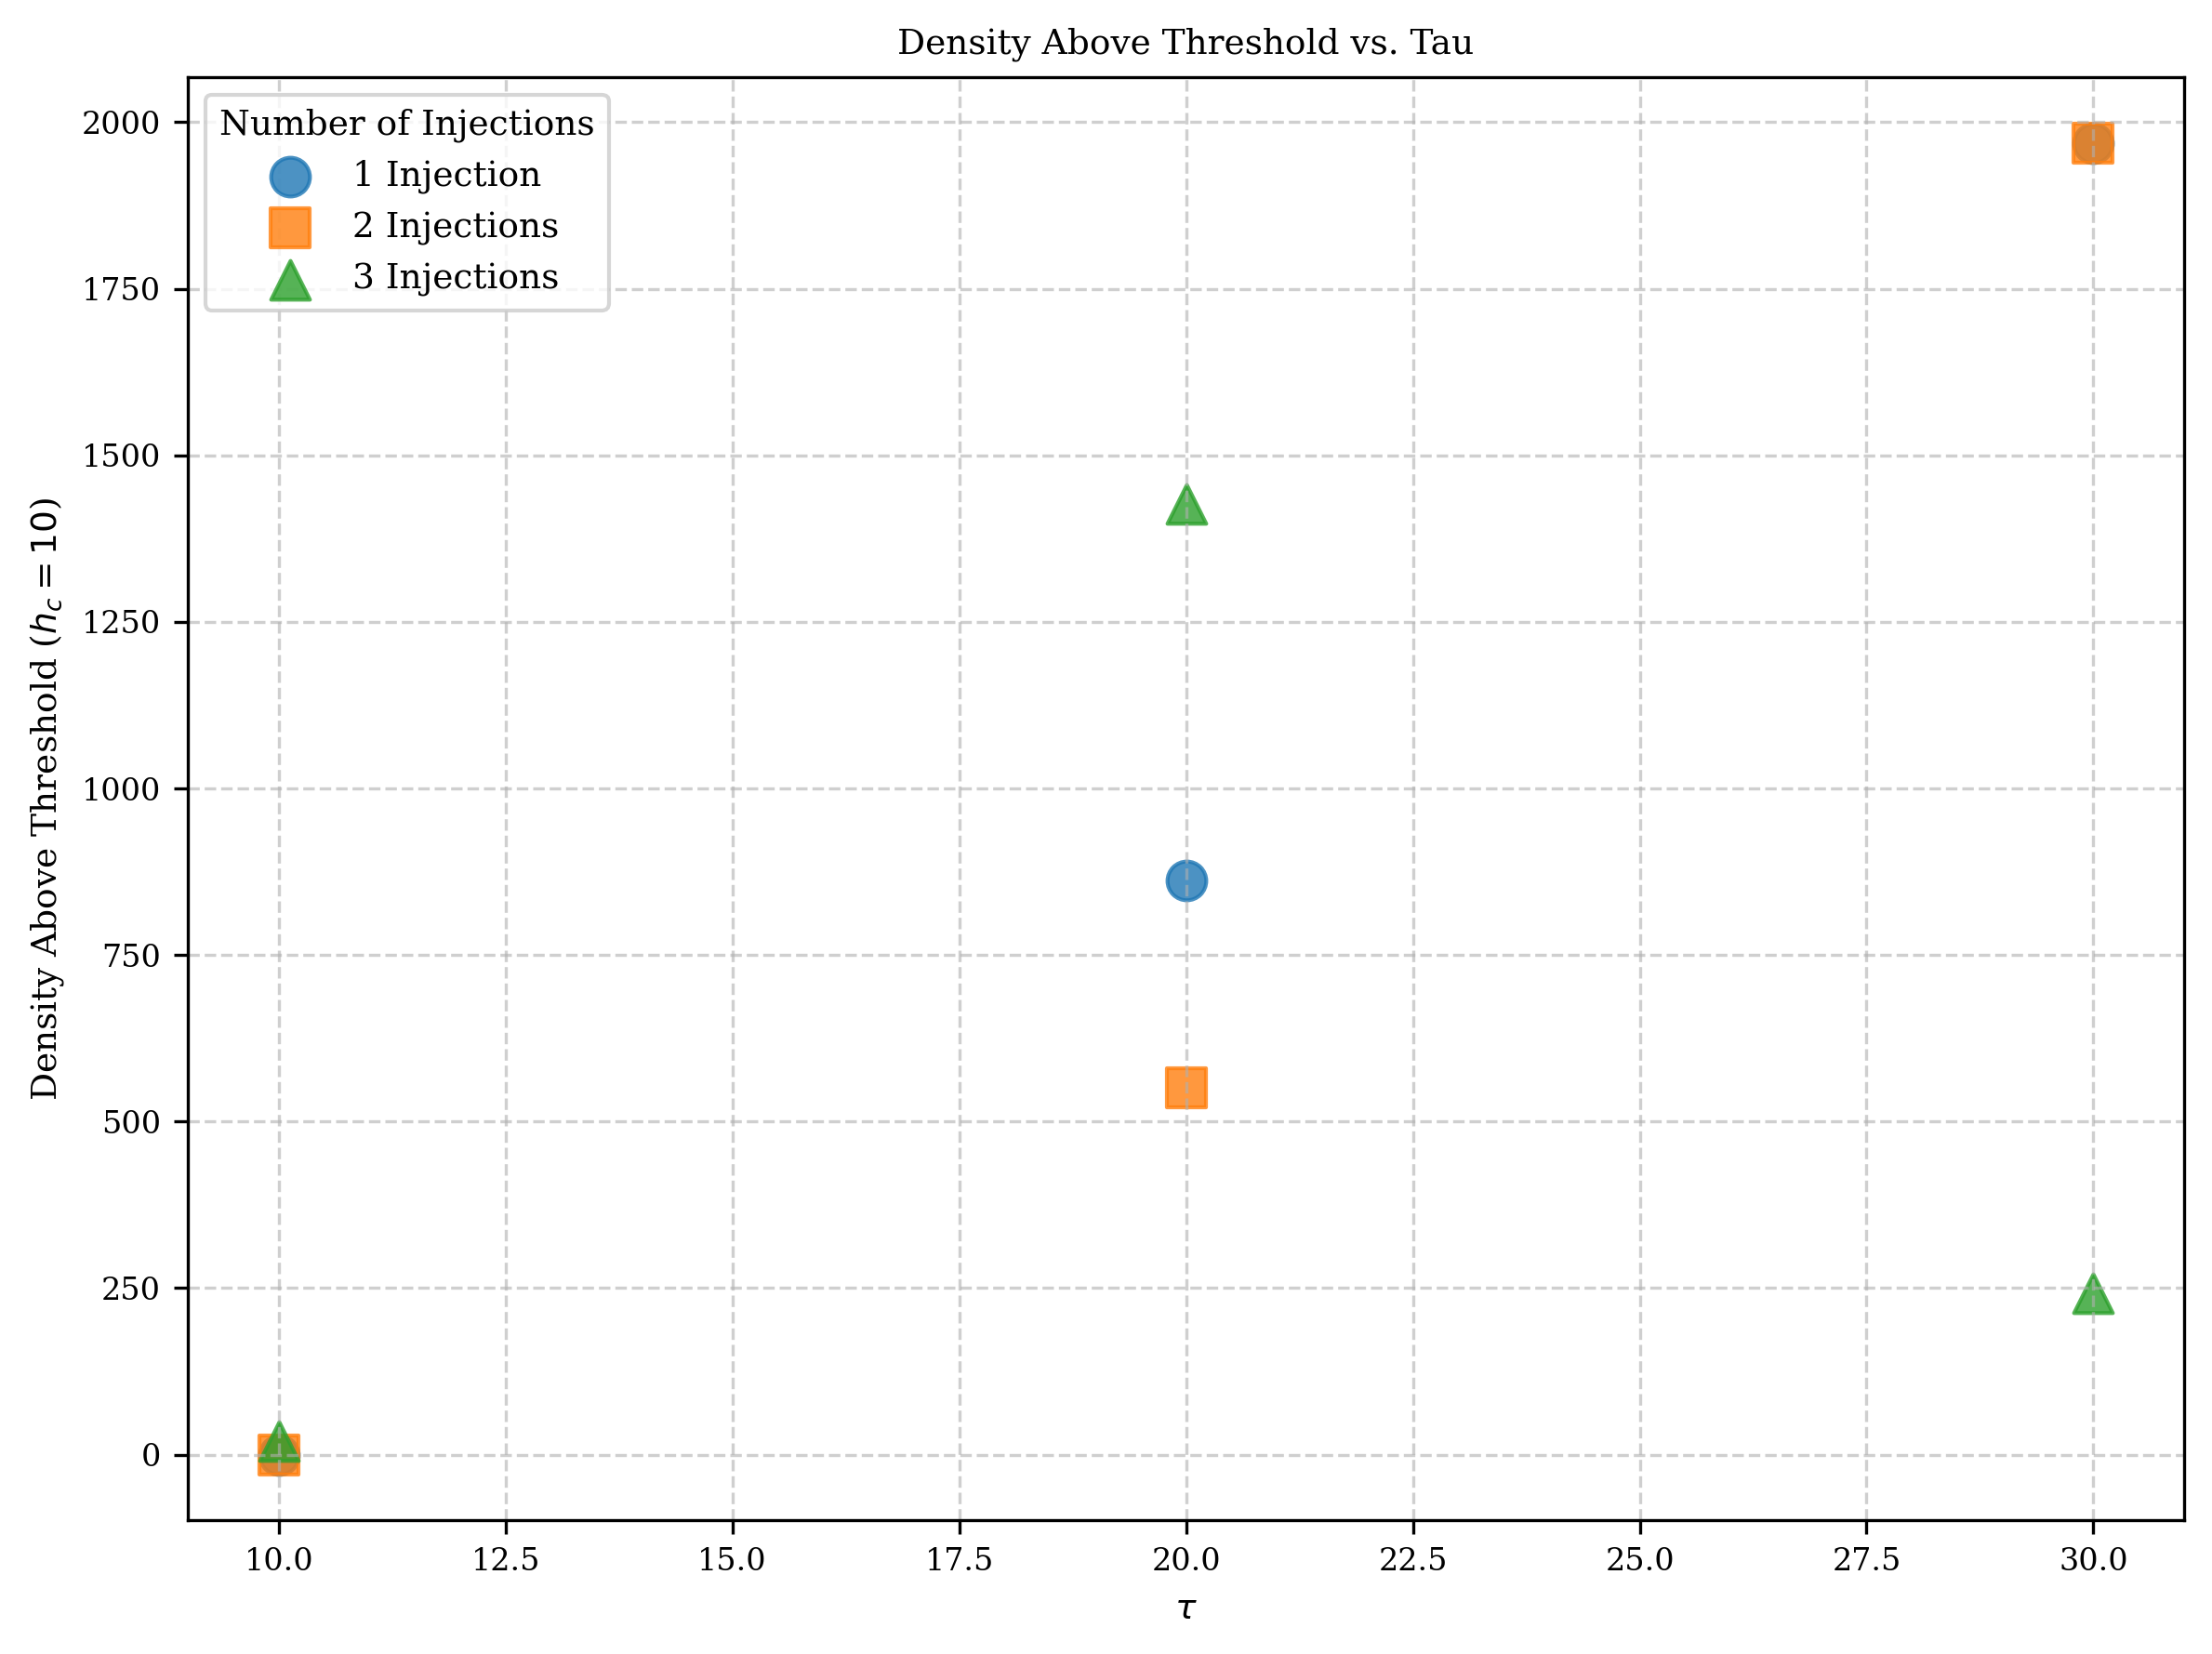

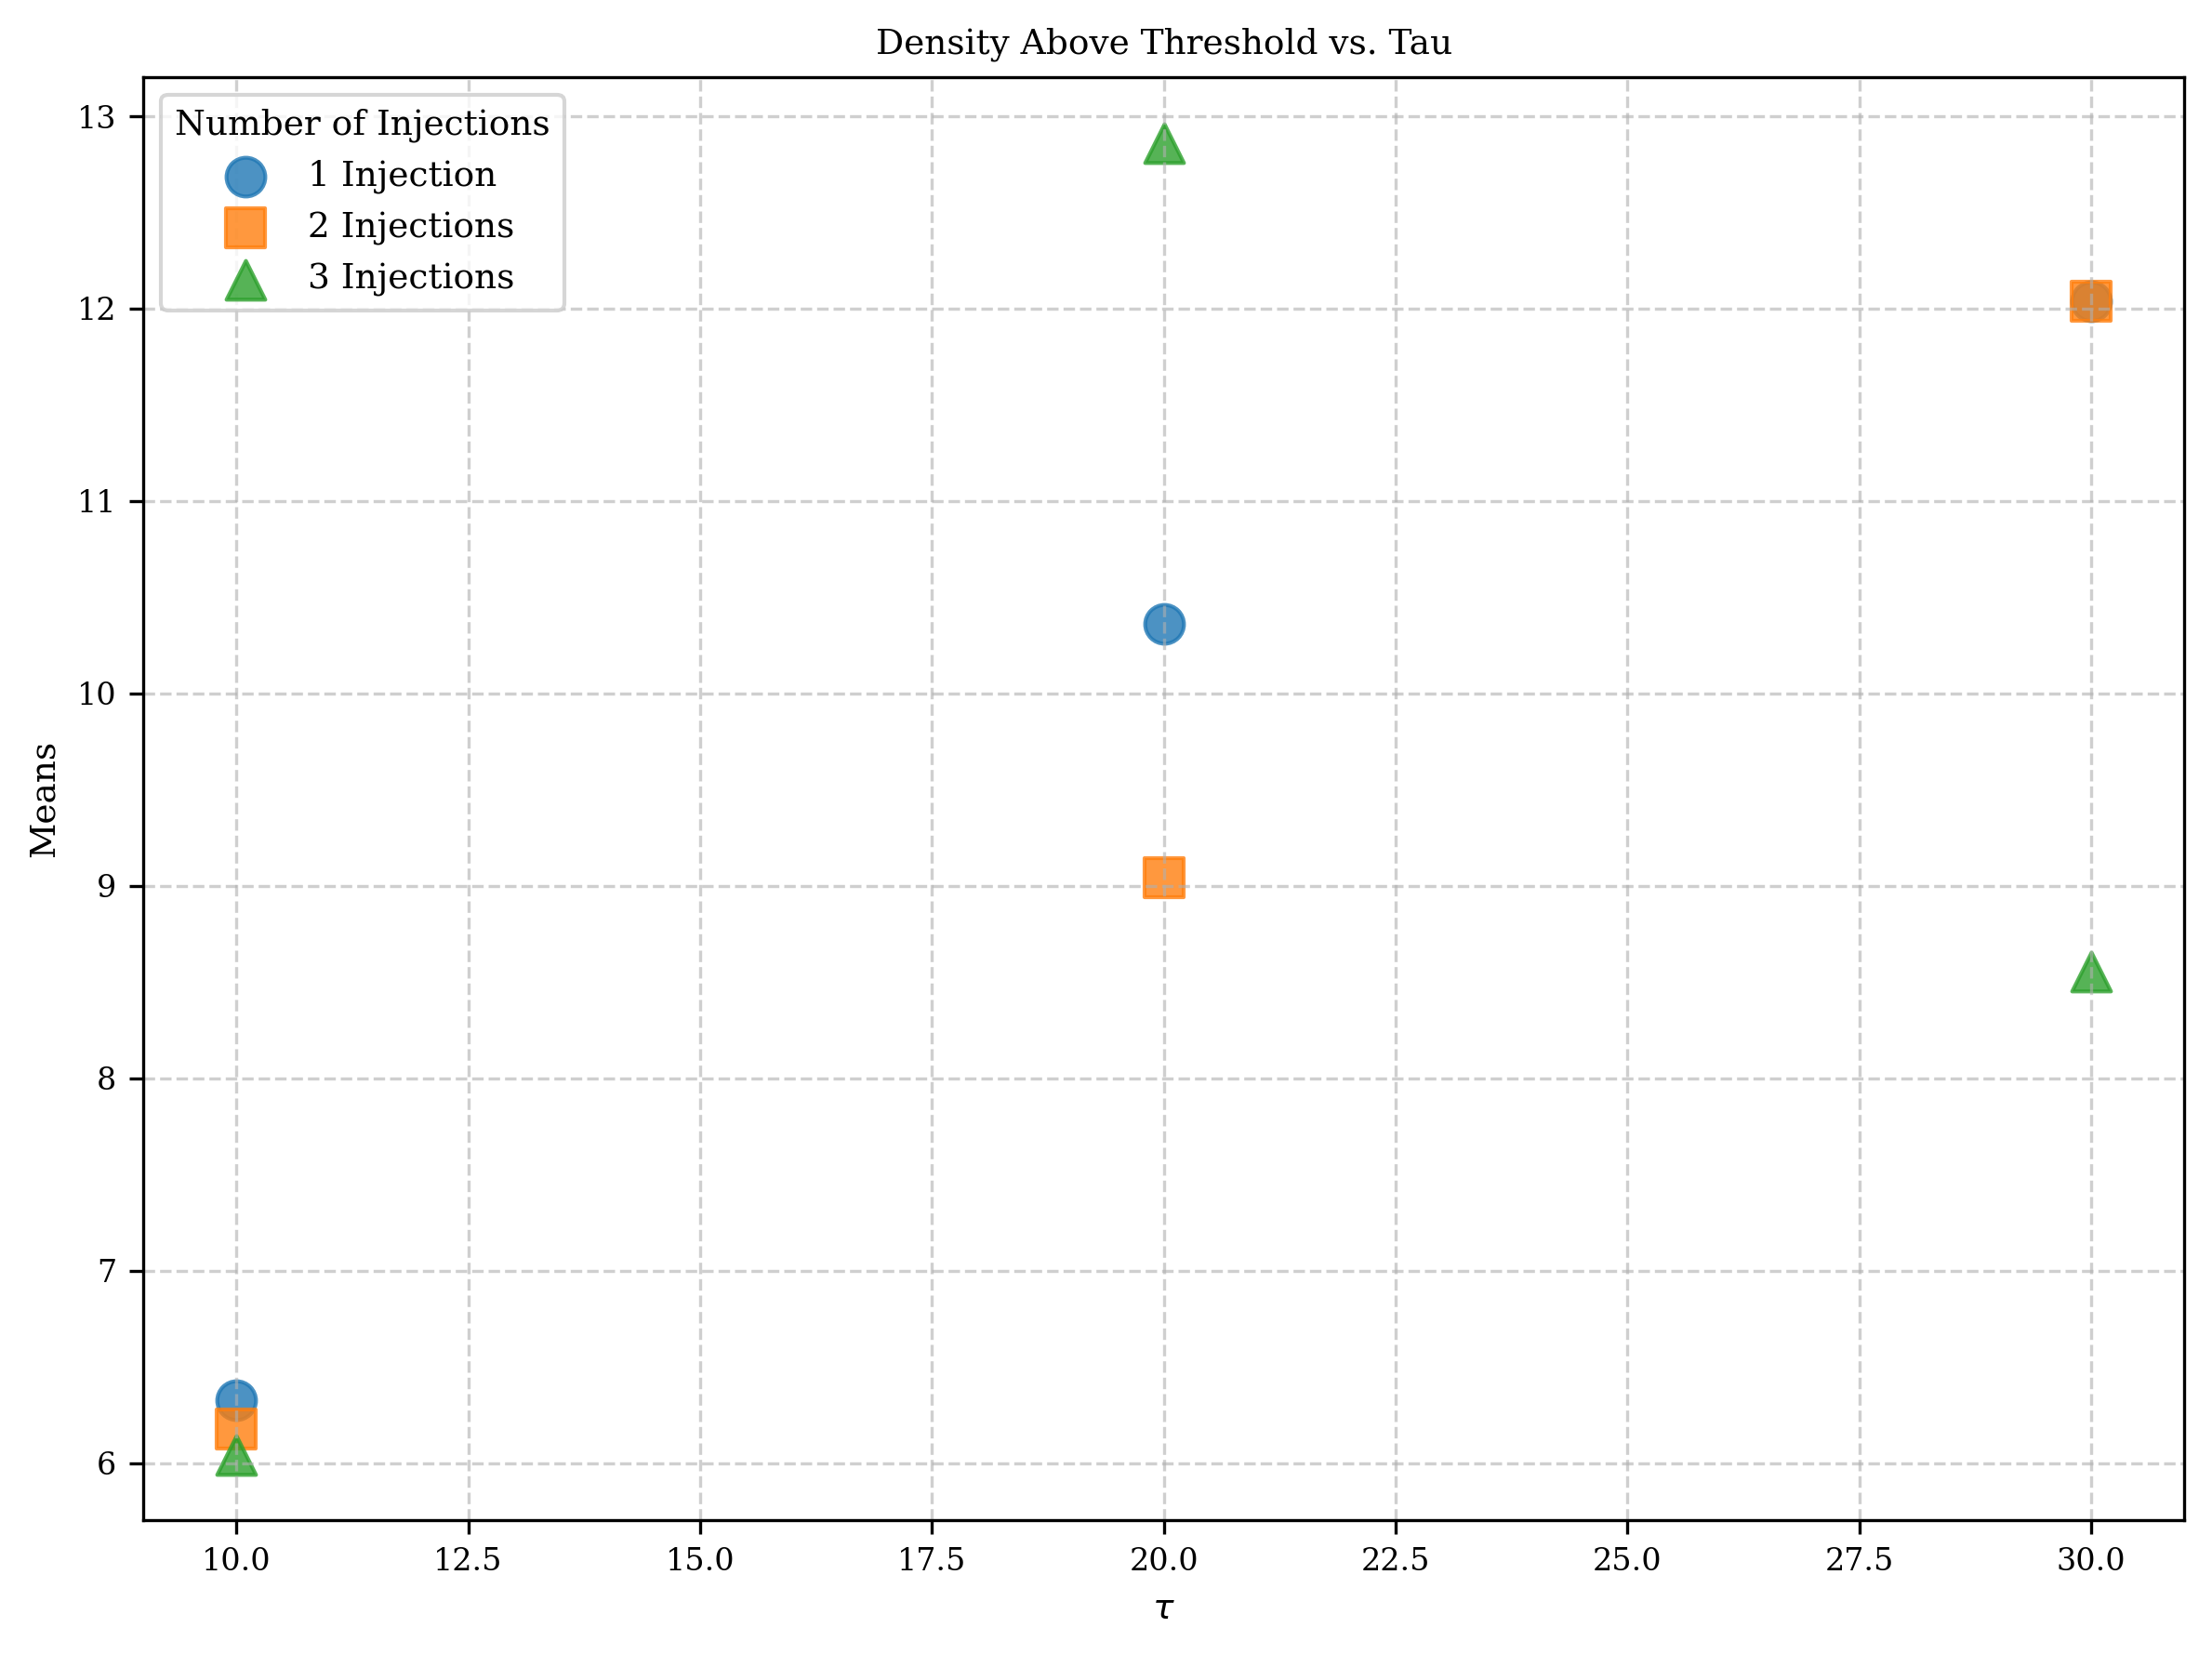

In [ ]:
# Plotting the results
plt.figure(figsize=(8, 6))

markers = {1: 'o', 2: 's', 3: '^'}
labels = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

for N_injections in N_inj_array:
    # Get the list of tuples for this specific N
    current_results = results[N_injections]
    
    # Extract just the scalars using list comprehensions and convert to arrays
    taus = np.array([item[0] for item in current_results])
    densities = np.array([item[1] for item in current_results])
    means = np.array([item[2] for item in current_results])
    
    # (Optional) If you need to access the specific arrays later:
    # all_concentrations = [item[2] for item in current_results]
    # all_injection_times = [item[3] for item in current_results]
    
    plt.scatter(
        taus, 
        densities, 
        # means,
        marker=markers[N_injections], 
        label=labels[N_injections],
        s=100,
        alpha=0.8
    )

plt.title('Density Above Threshold vs. Tau')
plt.xlabel(r'$\tau$')
plt.ylabel('Density Above Threshold ($h_c = 10$)')
plt.legend(title='Number of Injections')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plotting the results
plt.figure(figsize=(8, 6))

markers = {1: 'o', 2: 's', 3: '^'}
labels = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

for N_injections in N_inj_array:
    # Get the list of tuples for this specific N
    current_results = results[N_injections]
    
    # Extract just the scalars using list comprehensions and convert to arrays
    taus = np.array([item[0] for item in current_results])
    densities = np.array([item[1] for item in current_results])
    means = np.array([item[2] for item in current_results])
    
    # (Optional) If you need to access the specific arrays later:
    # all_concentrations = [item[2] for item in current_results]
    # all_injection_times = [item[3] for item in current_results]
    
    plt.scatter(
        taus, 
        # densities, 
        means,
        marker=markers[N_injections], 
        label=labels[N_injections],
        s=100,
        alpha=0.8
    )

plt.title('Density Above Threshold vs. Tau')
plt.xlabel(r'$\tau$')
plt.ylabel('Means')
plt.legend(title='Number of Injections')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

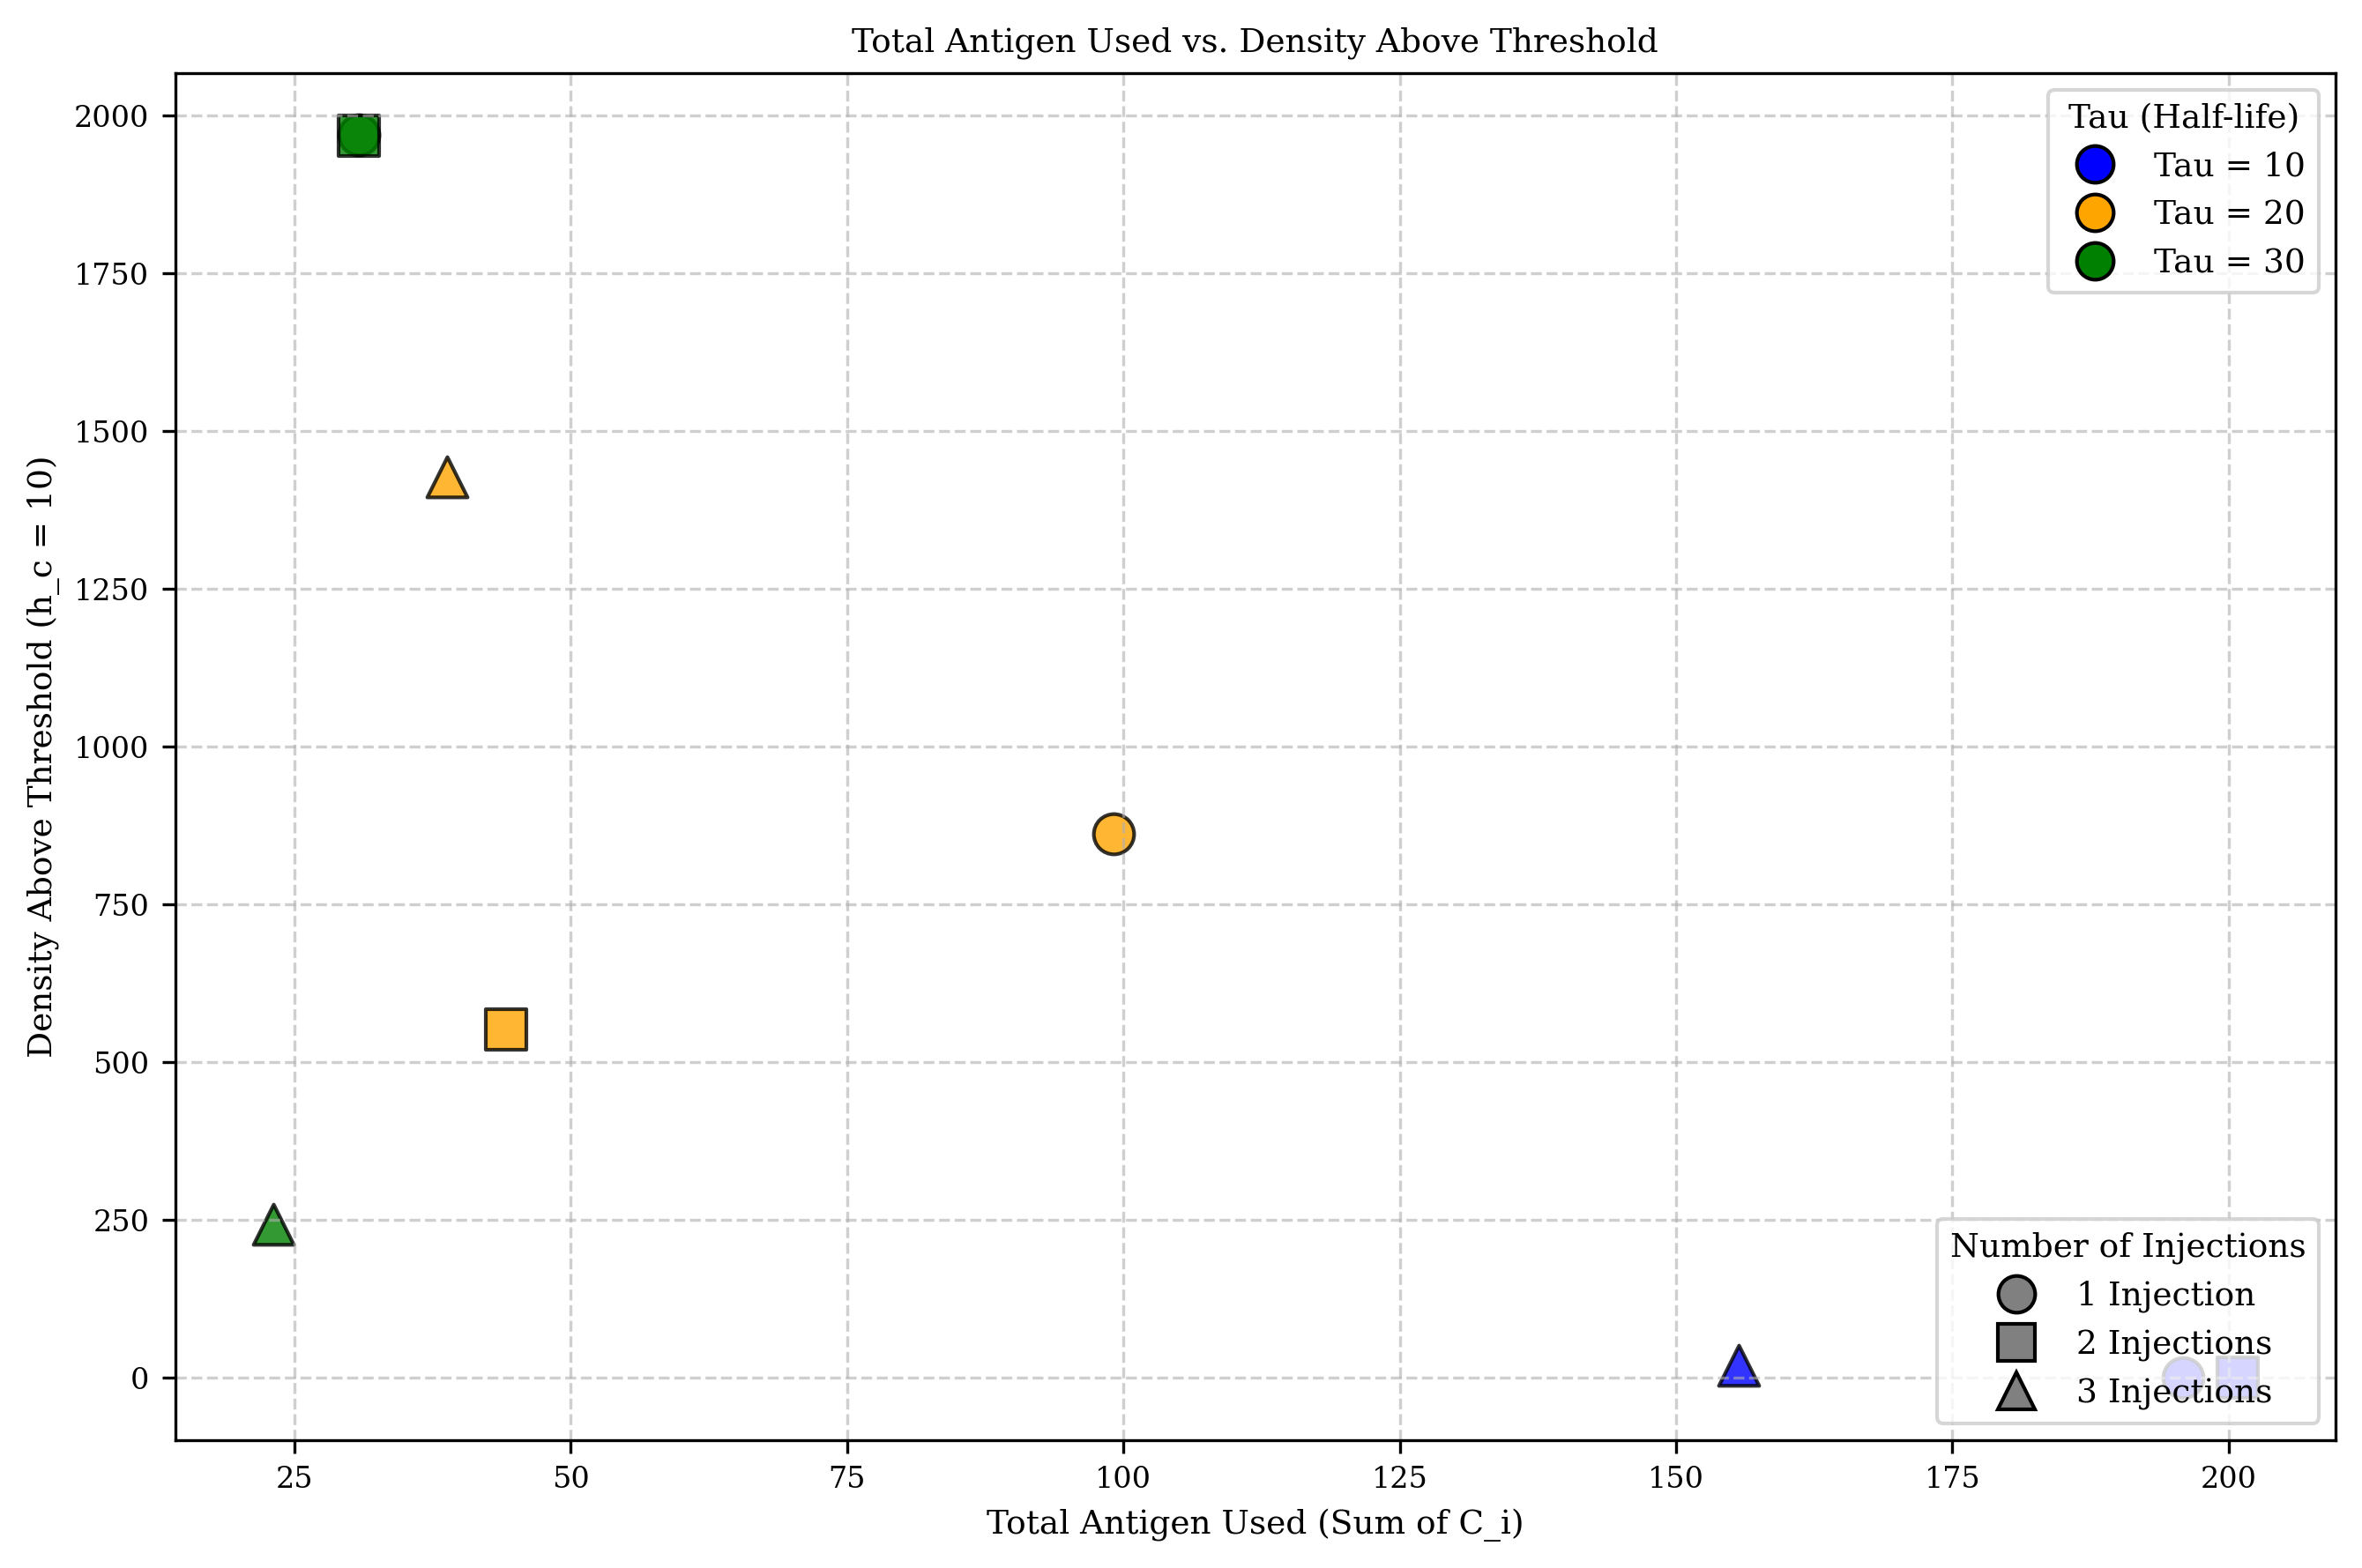

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(9, 6))

# Define markers mapped to Number of Injections
markers = {1: 'o', 2: 's', 3: '^'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

# Define colors mapped to Tau values
# (Ensure these match your actual Tau_array values)
colors = {10.0: 'blue', 20.0: 'orange', 30.0: 'green'}
labels_tau = {10.0: 'Tau = 10', 20.0: 'Tau = 20', 30.0: 'Tau = 30'}

# Loop through the data to plot each point
for N_injections in N_inj_array:
    current_results = results[N_injections]
    
    for item in current_results:
        tau_val = item[0]
        density = item[1]
        concentrations = item[3]
        
        # Total antigen is the sum of all optimized C values
        total_antigen = np.sum(concentrations)
        
        plt.scatter(
            total_antigen, 
            density, 
            marker=markers[N_injections], 
            color=colors[tau_val],
            s=120,
            alpha=0.8,
            edgecolors='k' # Add a black edge for better visibility
        )

# --- Create Custom Legends ---

# 1. Legend for Number of Injections (Markers, keeping color neutral)
legend_elements_markers = [
    mlines.Line2D([0], [0], marker=markers[n], color='w', label=labels_inj[n], 
                  markerfacecolor='gray', markeredgecolor='k', markersize=10) 
    for n in N_inj_array
]

# 2. Legend for Tau (Colors, keeping marker neutral)
legend_elements_colors = [
    mlines.Line2D([0], [0], marker='o', color='w', label=labels_tau[t], 
                  markerfacecolor=colors[t], markeredgecolor='k', markersize=10) 
    for t in Tau_array
]

# Add the first legend (Markers) and anchor it
leg1 = plt.legend(handles=legend_elements_markers, title='Number of Injections', loc='lower right')
plt.gca().add_artist(leg1) 

# Add the second legend (Colors)
plt.legend(handles=legend_elements_colors, title='Tau (Half-life)', loc='upper right')

plt.title('Total Antigen Used vs. Density Above Threshold')
plt.xlabel('Total Antigen Used (Sum of C_i)')
plt.ylabel('Density Above Threshold (h_c = 10)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Pareto plot

# Obsolete

In [ ]:
stop()

NameError: name 'stop' is not defined

In [ ]:
df=pd.read_csv("c_star_over_time.csv")
times=df["time"].values
c_star=df["c_star"].values

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_optimal_parameters_penalized(N, tau, t_eval_array, C_star_array, epochs=2000, lr=0.1, alpha=0.0):
    """
    Runs the gradient descent optimization with an L2 penalty on total antigen.
    
    Args:
        alpha (float): L2 penalization coefficient for total antigen used.
    """
    init_intervals = [20.0] * (N - 1)
    
    init_C_values = []
    for i in range(N):
        expected_time = i * 20.0
        idx = (np.abs(t_eval_array - expected_time)).argmin()
        val = max(float(C_star_array[idx]), 1e-4)
        init_C_values.append(val)

    t_tensor = torch.tensor(t_eval_array, dtype=torch.float32)
    C_star_tensor = torch.tensor(C_star_array, dtype=torch.float32)
    
    model = ImmunizationOptimizer(N, tau, init_C_values, init_intervals)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        current_steepness = 10.0 + (90.0 * epoch / epochs)
        
        # Forward pass
        C_simulated = model(t_tensor, sigmoid_steepness=current_steepness)
        C_i, _ = model.get_physical_parameters()
        
        # Compute Loss: MSE + L2 Penalty on Total Antigen
        mse_loss = loss_fn(torch.log(C_simulated + 1e-8), torch.log(C_star_tensor + 1e-8))
        total_antigen = torch.sum(C_i)
        penalty = alpha * (total_antigen ** 2) 
        
        loss = mse_loss + penalty
        
        loss.backward()
        optimizer.step()

    final_C, final_t = model.get_physical_parameters()
    
    return {
        "C_optimized": final_C.detach().numpy(),
        "t_optimized": final_t.detach().numpy(),
        "final_loss": loss.item(),
        "C_simulated": C_simulated.detach().numpy(),
        "total_antigen": np.sum(final_C.detach().numpy())
    }

In [ ]:
# Setup parameters
alphas = [0.0,  1e-3, 1e-4]  # Adjust these based on the scale of your C values
injections_list = [1, 2, 3]
tau_val = 20.0  # Replace with your actual tau
T = 140         # Replace with your actual T

simulation_results = []
# Assuming df, times, and c_star are already loaded
for N_inj in injections_list:
    for alpha in alphas:
        print(f"\n--- Running N={N_inj}, alpha={alpha} ---")
        
        # 1. Optimize schedule with current penalty
        result = find_optimal_parameters_penalized(N_inj, tau_val, times, c_star, alpha=alpha, epochs=2000)
        C_sim = result['C_simulated'].flatten()
        total_Ag = result['total_antigen']
        
        # 2. Setup continuous concentration function for the FP simulator
        get_C_star_vacc = make_get_C_from_cstar(times, C_sim)
        
        # 3. Run Fokker-Planck Simulation
        fp_ctx_opt = run_fp(
            get_S=lambda t: np.array([[1.0]]),  
            get_C=get_C_star_vacc,
            T=T,
            verbose=False
        )

        
    # Convert density to probability mass for accurate binning
        rho_last = fp_ctx_opt['rho_t'][-1]
        axes = fp_ctx_opt['axes']

        d_h = axes[0][1] - axes[0][0]
        dH = d_h ** len(axes)
        rho_mass_flat = rho_last.flatten() * dH 
        print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is OK
        
        # 4. Get marginal PDF and grid spacing
        # 4. Get marginal PDF and save raw results
        h1_opt, pdf_opt = _marginal_h1_pdf_max_above_hc(fp_ctx_opt)
        
        # Save the raw data instead of computing the threshold immediately
        simulation_results.append({
            'N_injections': N_inj,
            'alpha': alpha,
            'total_antigen': total_Ag,
            'h1_axis': h1_opt,
            'pdf': pdf_opt
        })

# Convert to DataFrame for easy handling



--- Running N=1, alpha=0.0 ---


C:\Users\maria\AppData\Local\Temp\ipykernel_2176\4109768839.py:94: RuntimeWarning: invalid value encountered in scalar divide
  Phi_bar = (rho * Phi).sum() * dH / N_pop


total mass check (should be close to N_i): nan

--- Running N=1, alpha=0.001 ---


C:\Users\maria\AppData\Local\Temp\ipykernel_2176\2298232161.py:22: RuntimeWarning: invalid value encountered in scalar divide
  Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)


total mass check (should be close to N_i): nan

--- Running N=1, alpha=0.0001 ---
total mass check (should be close to N_i): nan

--- Running N=2, alpha=0.0 ---
total mass check (should be close to N_i): 0.005931706629781278

--- Running N=2, alpha=0.001 ---
total mass check (should be close to N_i): nan

--- Running N=2, alpha=0.0001 ---
total mass check (should be close to N_i): 0.00011798506069841511

--- Running N=3, alpha=0.0 ---


KeyboardInterrupt: 

In [ ]:
def compute_pareto_points(sim_results, affinity_threshold=10.0):
    """
    Computes the number of high affinity B cells from saved simulation results.
    """
    pareto_data = []
    
    for res in sim_results:
        h1 = res['h1_axis']
        pdf = res['pdf']
        
        d_h = h1[1] - h1[0]
        
        # Compute number of high affinity B cells
        high_affinity_mask = h1 > affinity_threshold
        nb_high_affinity = np.sum(pdf[high_affinity_mask]) * d_h
        print(nb_high_affinity)
        
        pareto_data.append({
            'N_injections': res['N_injections'],
            'alpha': res['alpha'],
            'total_antigen': res['total_antigen'],
            'high_affinity_cells': nb_high_affinity
        })
        
    return pareto_data

# Assuming simulation_results was populated by your loop
pareto_data = compute_pareto_points(simulation_results, affinity_threshold=0)

# Convert to DataFrame for plotting
pareto_df = pd.DataFrame(pareto_data)

500.3350681660376
500.04100927786726
500.1067688517626
500.02924768653213
258.5432388576015
500.6485672007603
500.14923560808535
253.3883609701984
500.23348376678837


<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
C:\Users\maria\AppData\Local\Temp\ipykernel_2176\1832953701.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Total Antigen Dose ($\sum C_i$)')


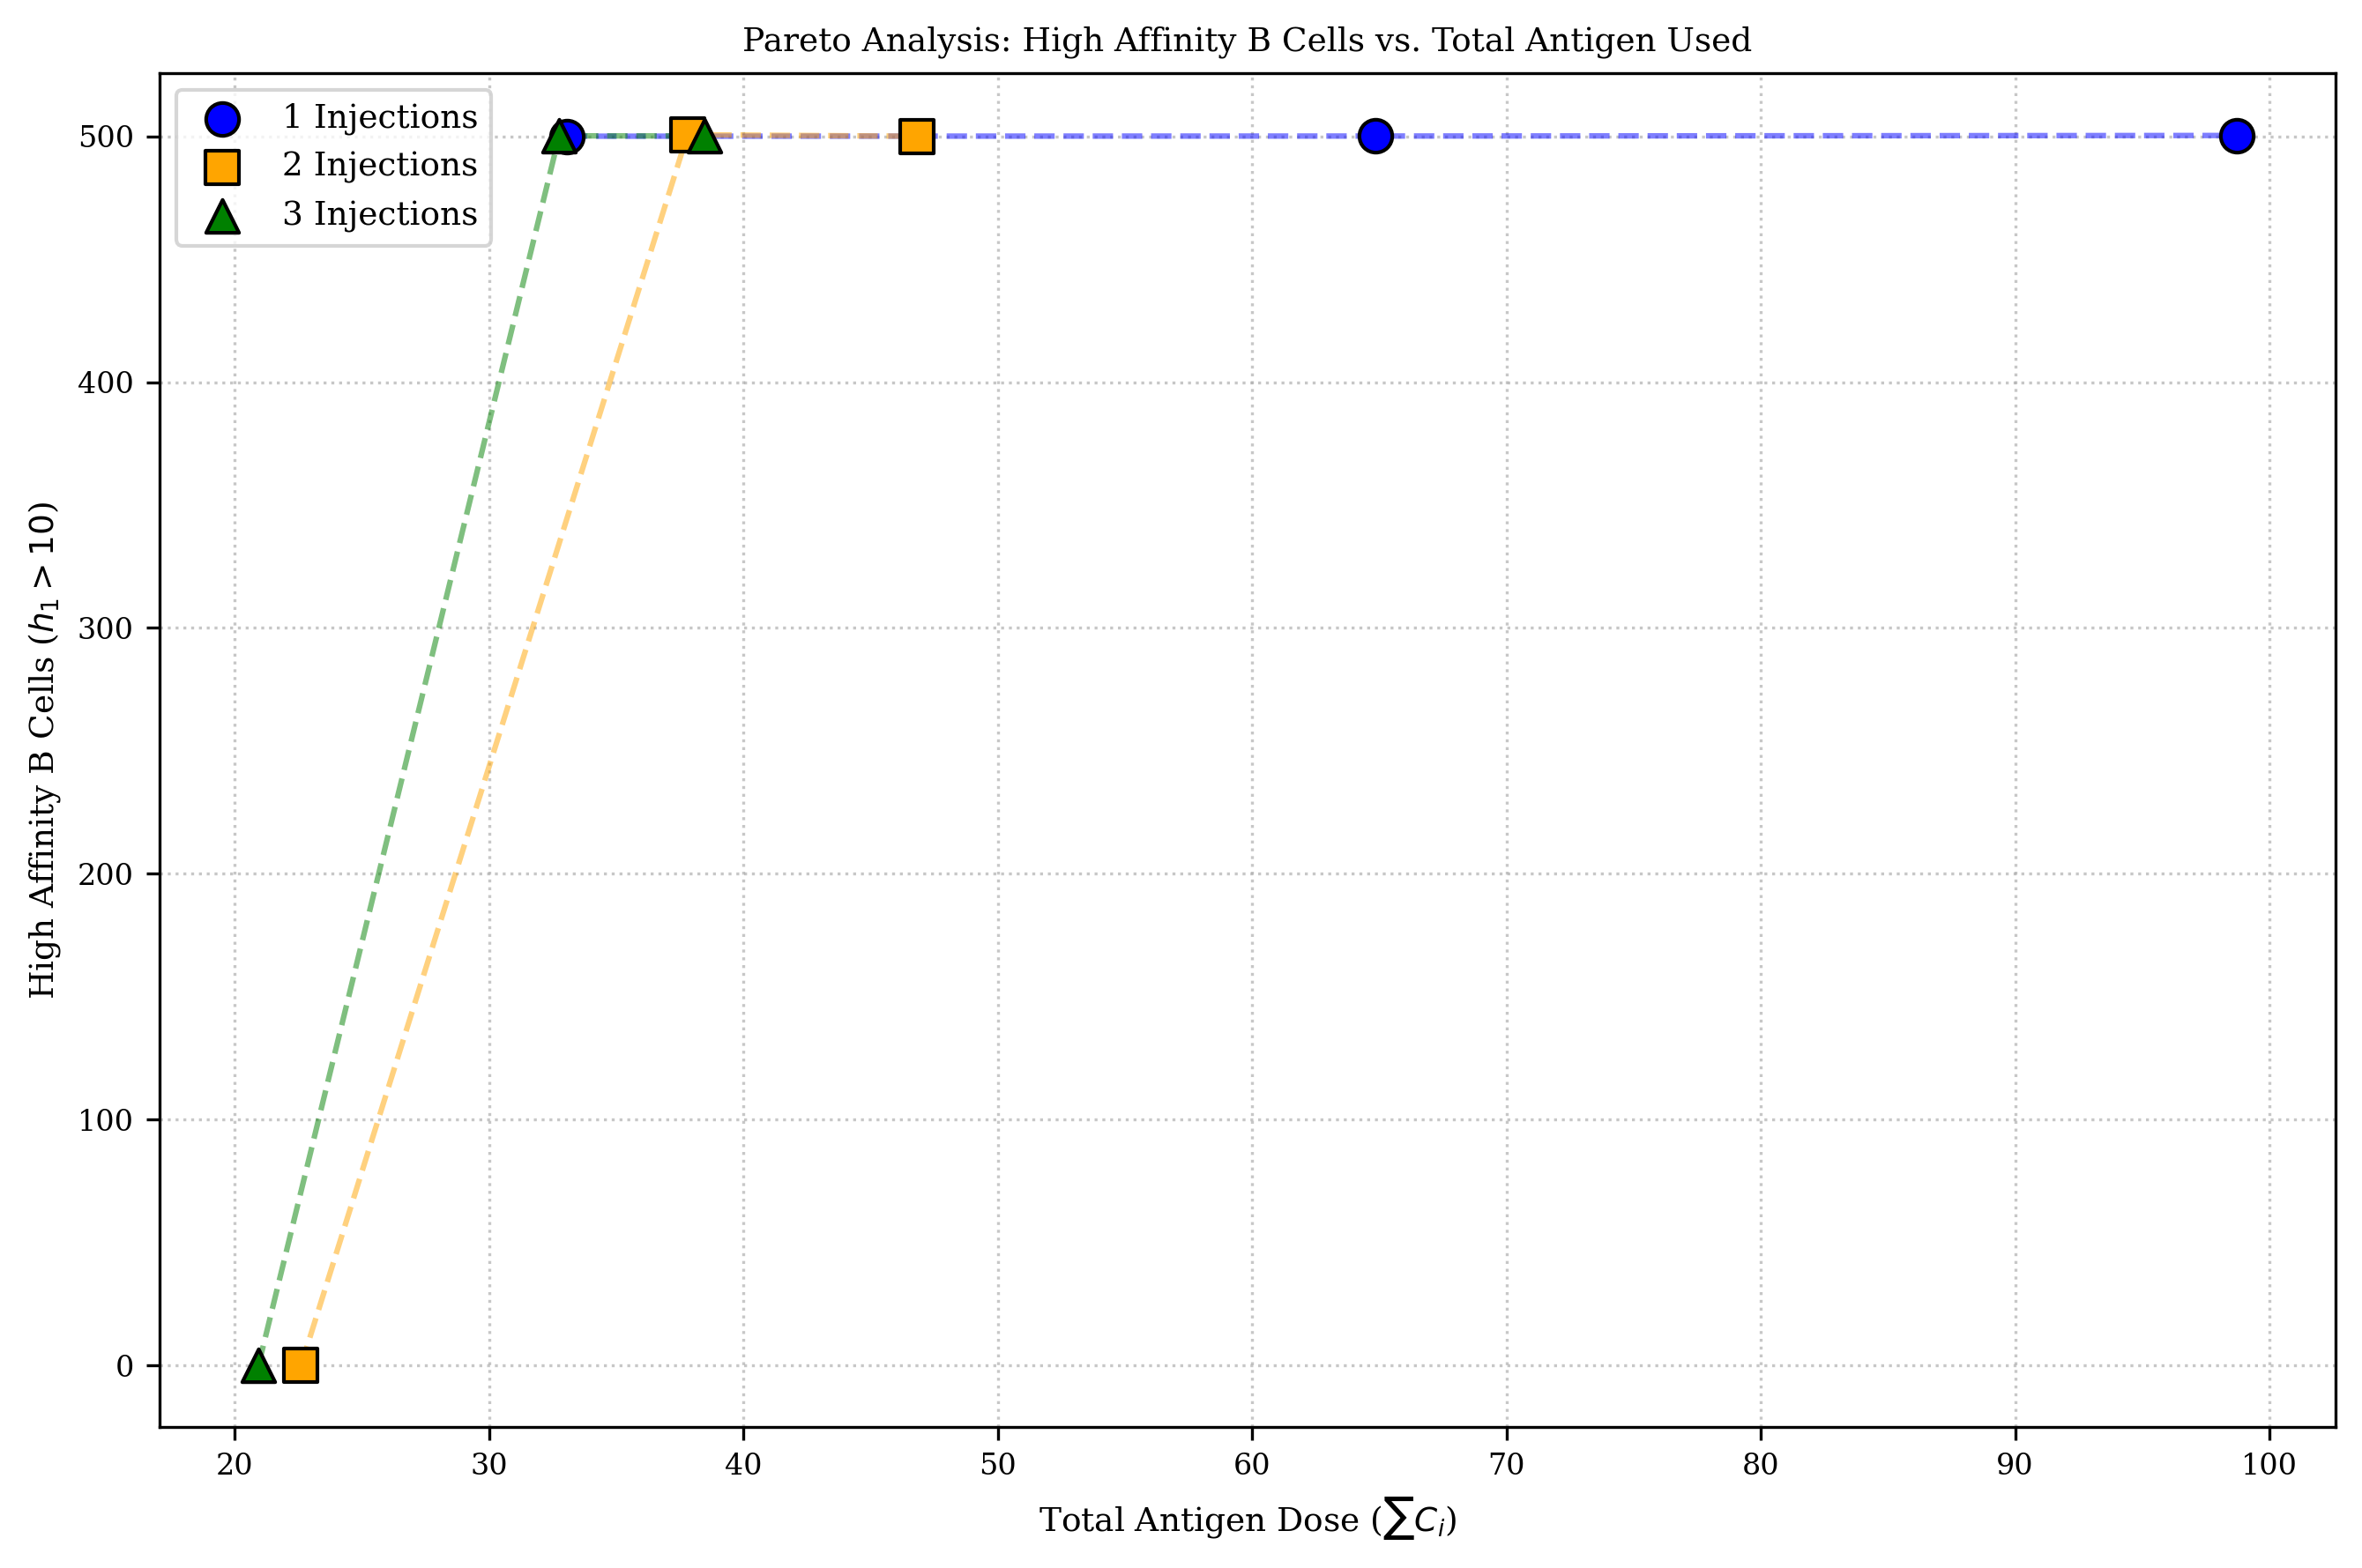

In [ ]:

# --- 6. Plotting the Pareto Front ---
plt.figure(figsize=(9, 6))

colors = {1: 'blue', 2: 'orange', 3: 'green'}
markers = {1: 'o', 2: 's', 3: '^'}

for N_inj in injections_list:
    subset = pareto_df[pareto_df['N_injections'] == N_inj]
    
    # Sort by total antigen to draw connecting lines properly
    subset = subset.sort_values(by='total_antigen')
    
    plt.plot(subset['total_antigen'], subset['high_affinity_cells'], 
             color=colors[N_inj], linestyle='--', alpha=0.5)
             
    plt.scatter(subset['total_antigen'], subset['high_affinity_cells'], 
                color=colors[N_inj], marker=markers[N_inj], s=80,
                label=f'{N_inj} Injections', edgecolor='k', zorder=5)

plt.title('Pareto Analysis: High Affinity B Cells vs. Total Antigen Used')
plt.xlabel('Total Antigen Dose ($\sum C_i$)')
plt.ylabel('High Affinity B Cells ($h_1 > 10$)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()